# 0. Title / Scope / Safety Notice

# KOEN-TP-RS-001 — AIHub Local Recon Evidence Export — G1 Sanitized Support

- This is **LOCAL_OBSERVED evidence only**.
- It does not establish official AI Hub dataset identity.
- It does not establish official version, official sentence count, human translation, translation validation workflow, license, or Tier A/B/C status.
- No raw text is exported.
- Only the three approved roots are inspected.
- Cross-dataset pooling is prohibited in this notebook.

본 notebook은 외부 web reconciliation을 위한 privacy-safe aggregate evidence exporter다. raw file을 수정하거나 normalization·tokenization·modeling을 수행하지 않는다.

- Rebuilt from released main without reusing any `eda/g0-raw-notebooks` blob.

# 1. Environment and Run Manifest

명령 실행 없이 고정된 설정값과 실행 환경을 기록한다. Sampling은 사용하지 않는다.

In [1]:
from __future__ import annotations

import hashlib, json, math, os, platform, re, subprocess, sys, unicodedata, warnings, zipfile
from collections import Counter, defaultdict
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from openpyxl import load_workbook

def discover_project_root(start=Path.cwd()):
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / 'pyproject.toml').is_file() and (candidate / 'src/tokenization_premium').is_dir():
            return candidate
    raise RuntimeError(f'Tokenization_Premium checkout not found from {start}')

DISCOVERED_PROJECT_ROOT = discover_project_root()
sys.path.insert(0, str(DISCOVERED_PROJECT_ROOT / 'src'))
from tokenization_premium.paths import PROJECT_ROOT
assert PROJECT_ROOT.resolve() == DISCOVERED_PROJECT_ROOT.resolve()
RAW_ROOT = Path(os.environ.get('TOKENIZATION_PREMIUM_RAW_ROOT', '/home/sieg/projects-wsl/Tokenization_Premium/data/raw/aigub')).expanduser().resolve()
NOTEBOOK_PATH = PROJECT_ROOT / 'notebooks/exploratory/evidence/AIHUB_LOCAL_RECON_EVIDENCE_EXPORT_20260816.ipynb'
OUTPUT_ROOT = PROJECT_ROOT / 'outputs/aihub_recon_g1'
FIGURE_ROOT = OUTPUT_ROOT / 'figures'
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
FIGURE_ROOT.mkdir(parents=True, exist_ok=True)

DATASETS = [
    {'label':'LOCAL_DIR_025','root':RAW_ROOT/'025.일상생활 및 구어체 한-영 번역 병렬 말뭉치 데이터'},
    {'label':'LOCAL_DIR_026','root':RAW_ROOT/'026.기술과학 분야 한-영 번역 병렬 말뭉치 데이터'},
    {'label':'LOCAL_LEGACY_KO_EN_XLSX','root':RAW_ROOT/'한국어-영어 번역(병렬) 말뭉치'},
]
ALLOWED_ROOTS = [item['root'].resolve() for item in DATASETS]
PREEXISTING_NOTEBOOK_ROWS = [{'relative_path': 'notebooks/00_environment_repro.ipynb', 'filename': '00_environment_repro.ipynb', 'extension': '.ipynb', 'bytes': 70728, 'modified_time': 'BASELINE_FILE', 'git_status_if_available': 'TRACKED', 'first_markdown_heading_or_blank': '00 — Environment / Repository Reproducibility', 'inferred_role': 'environment reproducibility', 'ai_hub_recon_relevant_boolean': False, 'notes': 'released main baseline'}, {'relative_path': 'notebooks/exploratory/raw/EDA_RAW_AIHUB_025_G1_SANITIZED.ipynb', 'filename': 'EDA_RAW_AIHUB_025_G1_SANITIZED.ipynb', 'extension': '.ipynb', 'bytes': 645824, 'modified_time': 'G1_REBUILD', 'git_status_if_available': 'NEW_G1_SUPPORT', 'first_markdown_heading_or_blank': 'AIHub 025 sanitized raw EDA', 'inferred_role': 'sanitized raw dataset exploratory EDA', 'ai_hub_recon_relevant_boolean': True, 'notes': 'aggregate-only; no old-branch blob reused'}, {'relative_path': 'notebooks/exploratory/raw/EDA_RAW_AIHUB_026_G1_SANITIZED.ipynb', 'filename': 'EDA_RAW_AIHUB_026_G1_SANITIZED.ipynb', 'extension': '.ipynb', 'bytes': 479611, 'modified_time': 'G1_REBUILD', 'git_status_if_available': 'NEW_G1_SUPPORT', 'first_markdown_heading_or_blank': 'AIHub 026 sanitized raw EDA', 'inferred_role': 'sanitized raw dataset exploratory EDA', 'ai_hub_recon_relevant_boolean': True, 'notes': 'aggregate-only; no old-branch blob reused'}, {'relative_path': 'notebooks/exploratory/raw/EDA_RAW_LEGACY_KO_EN_XLSX_G1_SANITIZED.ipynb', 'filename': 'EDA_RAW_LEGACY_KO_EN_XLSX_G1_SANITIZED.ipynb', 'extension': '.ipynb', 'bytes': 767910, 'modified_time': 'G1_REBUILD', 'git_status_if_available': 'NEW_G1_SUPPORT', 'first_markdown_heading_or_blank': 'Legacy KO-EN XLSX sanitized raw EDA', 'inferred_role': 'sanitized raw dataset exploratory EDA', 'ai_hub_recon_relevant_boolean': True, 'notes': 'aggregate-only; no old-branch blob reused'}]
RUN_TIMESTAMP_KST = datetime.now().astimezone().isoformat(timespec='seconds')
RUN_TIMESTAMP_UTC = datetime.now(timezone.utc).isoformat(timespec='seconds')
WITHIN_RUN_SALT = os.urandom(32)  # never printed or persisted
SAMPLING_USED = False
RANDOM_SEED = None

def git_value(*args):
    try:
        return subprocess.check_output(['git','-C',str(PROJECT_ROOT),*args], text=True, stderr=subprocess.DEVNULL).strip()
    except Exception:
        return 'UNAVAILABLE'

RUN_MANIFEST = {
    'run_timestamp_kst': RUN_TIMESTAMP_KST, 'run_timestamp_utc': RUN_TIMESTAMP_UTC,
    'os': platform.platform(), 'python': sys.version.split()[0],
    'notebook_path': NOTEBOOK_PATH.relative_to(PROJECT_ROOT).as_posix(),
    'project_root': 'CURRENT_CHECKOUT',
    'allowed_raw_roots': [(Path('data/raw/aigub')/root.relative_to(RAW_ROOT)).as_posix() for root in ALLOWED_ROOTS],
    'packages': {'pandas':pd.__version__,'numpy':np.__version__,'matplotlib':plt.matplotlib.__version__,'openpyxl':__import__('openpyxl').__version__},
    'git_branch': git_value('branch','--show-current'), 'git_head': git_value('rev-parse','HEAD'),
    'sampling_used': SAMPLING_USED, 'random_seed': RANDOM_SEED,
    'sampling_method': 'NONE; full-population streaming aggregates',
    'raw_source_files_modified': False,
    'configuration': {'hash':'SHA-256 files; keyed BLAKE2b-128 within-run duplicates','ratio_extreme':'<0.20 or >5.00','digit_high':'>0.20','punctuation_high':'>0.20','short':'<2 codepoints','long':'>1000 codepoints'},
}
display(RUN_MANIFEST)

HTML_RE = re.compile(r'<[A-Za-z/!][^>\n]{0,200}>')
URL_RE = re.compile(r'(?i)\b(?:https?://|www\.)\S+')
EMAIL_RE = re.compile(r'(?i)\b[A-Z0-9._%+-]+@[A-Z0-9.-]+\.[A-Z]{2,}\b')
PHONE_RE = re.compile(r'(?<!\d)(?:\+?\d[\d ()-]{7,}\d)(?!\d)')
BRACKET_PLACEHOLDER_RE = re.compile(r'(?:\[[A-Z_ -]{2,}\]|<[^>]{1,40}>|\{{[^}}]{1,40}\}})')
PII_PLACEHOLDER_RE = re.compile(r'(?i)(?:<|\[)(?:name|person|email|phone|address|id|pii|redacted|masked)(?:>|\])')
CONTROL_RE = re.compile(r'[\x00-\x08\x0b\x0c\x0e-\x1f\x7f]')
ZERO_WIDTH_RE = re.compile(r'[\u200b\u200c\u200d\u2060\ufeff]')
JAMO_RE = re.compile(r'[\u1100-\u11ff\u3130-\u318f\ua960-\ua97f\ud7b0-\ud7ff]')
SAFE_CATEGORY_FIELDS = {'data_set','domain','subdomain','source','style','source_language','target_language','license','대분류','소분류','발화자','자동분류1','자동분류2','자동분류3','언론사','키워드','지자체'}
CORE_METADATA_CONCEPTS = ['source','domain','style','document_id','direction','split','license','qc']

def sha256_file(path):
    digest=hashlib.sha256()
    with path.open('rb') as handle:
        for chunk in iter(lambda: handle.read(8*1024*1024), b''): digest.update(chunk)
    return digest.hexdigest()

def keyed_hash(text):
    return hashlib.blake2b(text.encode('utf-8'), key=WITHIN_RUN_SALT, digest_size=16).digest()

def safe_rel(path):
    resolved=path.resolve()
    project=PROJECT_ROOT.resolve()
    raw=RAW_ROOT.resolve()
    if resolved == project or project in resolved.parents:
        return resolved.relative_to(project).as_posix()
    if resolved == raw or raw in resolved.parents:
        suffix=resolved.relative_to(raw)
        return (Path('data/raw/aigub')/suffix).as_posix()
    raise ValueError(f'path is outside project and raw roots: {path.name}')

def ensure_allowed(path):
    resolved=path.resolve()
    if not any(resolved == root or root in resolved.parents for root in ALLOWED_ROOTS):
        raise PermissionError(f'OUTSIDE_ALLOWED_ROOT: {safe_rel(path) if PROJECT_ROOT in resolved.parents else path.name}')

def iter_json_data(path):
    ensure_allowed(path)
    decoder=json.JSONDecoder(); prefix=''; match=None
    with path.open('r',encoding='utf-8-sig',errors='strict') as handle:
        while match is None:
            chunk=handle.read(1024*1024)
            if not chunk: raise ValueError('root.data array not found')
            prefix += chunk; match=re.search(r'"data"\s*:\s*\[',prefix)
        buffer,position=prefix[match.end():],0
        while True:
            while True:
                while position < len(buffer) and buffer[position] in ' \t\r\n,': position += 1
                if position < len(buffer): break
                buffer,position=handle.read(4*1024*1024),0
                if not buffer: raise ValueError('unexpected EOF')
            if buffer[position] == ']': return
            while True:
                try: value,end=decoder.raw_decode(buffer,position); break
                except json.JSONDecodeError:
                    remainder=buffer[position:]; chunk=handle.read(4*1024*1024)
                    if not chunk: raise
                    buffer,position=remainder+chunk,0
            if not isinstance(value,dict): raise TypeError('root.data member is not object')
            yield value; position=end
            if position > 8*1024*1024: buffer,position=buffer[position:],0

def scalar_type(value):
    if value is None: return 'null'
    if isinstance(value,bool): return 'boolean'
    if isinstance(value,int): return 'integer'
    if isinstance(value,float): return 'number'
    if isinstance(value,str): return 'string'
    if isinstance(value,datetime): return 'datetime'
    if isinstance(value,list): return 'array'
    if isinstance(value,dict): return 'object'
    return type(value).__name__

def chars(text):
    counts=Counter()
    for ch in text:
        category=unicodedata.category(ch)
        if '\uac00' <= ch <= '\ud7a3' or '\u3130' <= ch <= '\u318f': counts['hangul'] += 1
        elif ('a' <= ch.lower() <= 'z'): counts['latin'] += 1
        elif ch.isdigit(): counts['digit'] += 1
        elif ch.isspace(): counts['whitespace'] += 1
        elif category.startswith('P'): counts['punctuation'] += 1
        elif category in {'So','Sk'}: counts['emoji_symbol'] += 1
        else: counts['other'] += 1
    return counts

def q_from_hist(hist, probability):
    total=sum(hist.values()); target=max(1,math.ceil(total*probability)); cumulative=0
    for value,count in sorted(hist.items()):
        cumulative += count
        if cumulative >= target: return value
    return 0

def family_name(path, dataset_label):
    name=path.name
    if path.suffix.lower()=='.json':
        split='TRAIN' if '/1.Training/' in '/'+safe_rel(path) else 'VALID' if '/2.Validation/' in '/'+safe_rel(path) else 'UNSPLIT'
        direction='EN_TO_KO' if '영한' in name else 'KO_TO_EN' if '한영' in name else 'UNKNOWN'
        return f'{split}_{direction}'
    if name.startswith('1_구어체'): return name.replace('.xlsx','')
    if name.startswith('2_대화체'): return '2_대화체'
    if name.startswith('3_문어체_뉴스'): return name.replace('.xlsx','')
    if name.startswith('4_문어체_한국문화'): return '4_한국문화'
    if name.startswith('5_문어체_조례'): return '5_조례'
    if name.startswith('6_문어체_지자체'): return '6_지자체웹'
    return path.stem

def field_flags(field):
    low=field.lower()
    return {
        'candidate_text': low in {'ko','en','ko_original','en_original','mt','원문','번역문'},
        'candidate_id': low in {'sn','id','sid'} or low.endswith('_id'),
        'candidate_metadata': low not in {'ko','en','ko_original','en_original','mt','원문','번역문'},
        'suggests_korean': low in {'ko','ko_original','원문'} or 'korean' in low,
        'suggests_english': low in {'en','en_original','번역문'} or 'english' in low,
        'suggests_translation': any(token in low for token in ['source','target','original','translation','번역','원문','mt']),
        'suggests_cleaning': any(token in low for token in ['clean','normal','preprocess','mask','redact','정제','정규']),
    }

def concept_for_field(field):
    low=field.lower()
    if low in {'source','file_name','언론사'}: return 'source'
    if low in {'domain','subdomain','대분류','소분류','자동분류1','자동분류2','자동분류3','키워드','지자체'}: return 'domain'
    if low in {'style','genre','register','상황'}: return 'style'
    if low in {'sn','id','sid'}: return 'document_id'
    if low in {'source_language','target_language','direction'}: return 'direction'
    if low in {'split','train','validation','test'}: return 'split'
    if low in {'license','copyright'}: return 'license'
    if low in {'ner','included_unknown_words','quality_score','confidence'}: return 'qc'
    if low in {'날짜','date','time','timestamp'}: return 'date_time'
    if low in {'발화자','speaker','author','transcriber'}: return 'author_speaker'
    if low in {'url','source_url'}: return 'url'
    if any(token in low for token in ['annotator','reviewer','translator','provider']): return 'translation_actor'
    if any(token in low for token in ['pii','redact','mask']): return 'pii_masking'
    if any(token in low for token in ['clean','normal','preprocess']): return 'preprocessing'
    return 'other'

def bounded_category_json(categories, max_chars=190):
    """Keep a valid aggregate-only JSON summary below the export string limit."""
    bounded={}
    for field,pairs in categories.items():
        for value,count in pairs:
            trial={key:list(items) for key,items in bounded.items()}
            trial.setdefault(field,[]).append([value,count])
            rendered=json.dumps(trial,ensure_ascii=False,separators=(',',':'))
            if len(rendered) <= max_chars:
                bounded=trial
            else:
                break
    return json.dumps(bounded,ensure_ascii=False,separators=(',',':')) if bounded else ''

def role_from_filename(path):
    name=path.name.lower()
    if path.suffix.lower() in {'.zip','.tar','.gz','.7z'}: return 'archive'
    if path.suffix.lower() in {'.xlsx','.xls'}: return 'spreadsheet'
    if 'metadata' in name: return 'metadata'
    if any(token in name for token in ['guide','readme','설명']): return 'guide'
    if 'label' in name: return 'label'
    if 'raw' in name: return 'raw'
    return 'unknown'

def inspect_container(path):
    suffix=path.suffix.lower(); details={}; status='PARSEABLE'; error=''
    try:
        if suffix=='.zip':
            with zipfile.ZipFile(path) as archive:
                bad=archive.testzip()
                details={'members':[{'name':m.filename,'bytes':m.file_size} for m in archive.infolist()],'bad_member':bad}
        elif suffix=='.xlsx':
            warnings.filterwarnings('ignore',message='Workbook contains no default style')
            wb=load_workbook(path,read_only=True,data_only=True)
            sheets=[]
            for ws in wb.worksheets:
                first=next(ws.iter_rows(min_row=1,max_row=1,values_only=True),())
                headers=[str(v) if v not in (None,'') else '<EMPTY_HEADER>' for v in first]
                while headers and headers[-1]=='<EMPTY_HEADER>': headers.pop()
                sheets.append({'sheet':ws.title,'max_row':ws.max_row,'max_column':ws.max_column,'headers':headers})
            wb.close(); details={'sheets':sheets}
        elif suffix=='.json':
            with path.open('r',encoding='utf-8-sig',errors='strict') as handle:
                prefix=handle.read(1024*1024)
            details={'top_level_type':'object' if prefix.lstrip().startswith('{') else 'list' if prefix.lstrip().startswith('[') else 'unknown','candidate_record_path':'root.data[*]' if re.search(r'"data"\s*:\s*\[',prefix) else 'unknown'}
        else: status='UNSUPPORTED'
    except Exception as exc:
        status='ERROR'; error=type(exc).__name__
    return status,error,details


{'run_timestamp_kst': '2026-08-16T17:33:25+09:00',
 'run_timestamp_utc': '2026-08-16T08:33:25+00:00',
 'os': 'Linux-6.18.33.2-microsoft-standard-WSL2-x86_64-with-glibc2.39',
 'python': '3.12.3',
 'notebook_path': 'notebooks/exploratory/evidence/AIHUB_LOCAL_RECON_EVIDENCE_EXPORT_20260816.ipynb',
 'project_root': 'CURRENT_CHECKOUT',
 'allowed_raw_roots': ['data/raw/aigub/025.일상생활 및 구어체 한-영 번역 병렬 말뭉치 데이터',
  'data/raw/aigub/026.기술과학 분야 한-영 번역 병렬 말뭉치 데이터',
  'data/raw/aigub/한국어-영어 번역(병렬) 말뭉치'],
 'packages': {'pandas': '2.3.3',
  'numpy': '2.5.2',
  'matplotlib': '3.11.1',
  'openpyxl': '3.1.5'},
 'git_branch': 'eda/g1-support',
 'git_head': '2e11112eb4b545d76c20f09d7071e7b477e09985',
 'sampling_used': False,
 'random_seed': None,
 'sampling_method': 'NONE; full-population streaming aggregates',
 'raw_source_files_modified': False,
 'configuration': {'hash': 'SHA-256 files; keyed BLAKE2b-128 within-run duplicates',
  'ratio_extreme': '<0.20 or >5.00',
  'digit_high': '>0.20',
  'punctuation

# 2. Existing Notebook Inventory

생성 전 snapshot을 고정했다. 첫 Markdown heading만 role 추론에 사용하며 cell content는 export하지 않는다.

In [2]:
notebook_inventory_df=pd.DataFrame(PREEXISTING_NOTEBOOK_ROWS)
notebook_inventory_df.to_csv(OUTPUT_ROOT/'notebook_inventory.csv',index=False,encoding='utf-8')
display(notebook_inventory_df)
RELEVANT_NOTEBOOKS=notebook_inventory_df.loc[notebook_inventory_df.ai_hub_recon_relevant_boolean,'relative_path'].tolist()
REUSE_RECORD={'source_notebooks':RELEVANT_NOTEBOOKS,'reused_sections':'streaming JSON/XLSX aggregation, SHA de-aliasing, aggregate length/noise plots','differences':'no raw preview; salted in-memory alignment hashes; 15 reconciliation plots; required privacy exports','results':'RE-RUN_FROM_RAW; prior outputs not reused'}
display(REUSE_RECORD)

,relative_path,filename,extension,bytes,modified_time,git_status_if_available,first_markdown_heading_or_blank,inferred_role,ai_hub_recon_relevant_boolean,notes
0,notebooks/00_environment_repro.ipynb,00_environment_repro.ipynb,.ipynb,70728,BASELINE_FILE,TRACKED,00 — Environment / Repository Reproducibility,environment reproducibility,False,released main baseline
1,notebooks/exploratory/raw/EDA_RAW_AIHUB_025_G1...,EDA_RAW_AIHUB_025_G1_SANITIZED.ipynb,.ipynb,645824,G1_REBUILD,NEW_G1_SUPPORT,AIHub 025 sanitized raw EDA,sanitized raw dataset exploratory EDA,True,aggregate-only; no old-branch blob reused
2,notebooks/exploratory/raw/EDA_RAW_AIHUB_026_G1...,EDA_RAW_AIHUB_026_G1_SANITIZED.ipynb,.ipynb,479611,G1_REBUILD,NEW_G1_SUPPORT,AIHub 026 sanitized raw EDA,sanitized raw dataset exploratory EDA,True,aggregate-only; no old-branch blob reused
3,notebooks/exploratory/raw/EDA_RAW_LEGACY_KO_EN...,EDA_RAW_LEGACY_KO_EN_XLSX_G1_SANITIZED.ipynb,.ipynb,767910,G1_REBUILD,NEW_G1_SUPPORT,Legacy KO-EN XLSX sanitized raw EDA,sanitized raw dataset exploratory EDA,True,aggregate-only; no old-branch blob reused


{'source_notebooks': ['notebooks/exploratory/raw/EDA_RAW_AIHUB_025_G1_SANITIZED.ipynb',
  'notebooks/exploratory/raw/EDA_RAW_AIHUB_026_G1_SANITIZED.ipynb',
  'notebooks/exploratory/raw/EDA_RAW_LEGACY_KO_EN_XLSX_G1_SANITIZED.ipynb'],
 'reused_sections': 'streaming JSON/XLSX aggregation, SHA de-aliasing, aggregate length/noise plots',
 'differences': 'no raw preview; salted in-memory alignment hashes; 15 reconciliation plots; required privacy exports',
 'results': 'RE-RUN_FROM_RAW; prior outputs not reused'}

# 3. Approved Dataset Root Registry

Directory names remain local labels. Official ID/title/version are not inferred.

In [3]:
registry=[]; RAW_START_STATE={}
for item in DATASETS:
    root=item['root']; ensure=root.resolve(); assert ensure in ALLOWED_ROOTS
    files=sorted([p for p in root.rglob('*') if p.is_file()]); RAW_START_STATE.update({safe_rel(p):(p.stat().st_size,p.stat().st_mtime_ns) for p in files})
    extensions=Counter(p.suffix.lower() for p in files)
    registry.append({'local_dataset_label':item['label'],'local_root_relative_path':safe_rel(root),'local_root_exists':root.is_dir(),'local_root_bytes_total':sum(p.stat().st_size for p in files),'local_file_count':len(files),'local_archive_count':sum(extensions[e] for e in ['.zip','.tar','.gz','.7z']),'local_json_count':extensions['.json'],'local_xlsx_count':extensions['.xlsx'],'local_csv_count':extensions['.csv'],'local_txt_count':extensions['.txt'],'local_other_count':len(files)-sum(extensions[e] for e in ['.zip','.tar','.gz','.7z','.json','.xlsx','.csv','.txt']),'observed_directory_names':'|'.join(sorted({p.name for p in root.iterdir() if p.is_dir()})),'official_dataset_id_claim':'NOT VERIFIED','official_title_claim':'NOT VERIFIED','official_version_claim':'NOT VERIFIED','identity_status':'LOCAL_FILENAME_ONLY'})
dataset_inventory_df=pd.DataFrame(registry); dataset_inventory_df.to_csv(OUTPUT_ROOT/'aihub_dataset_inventory.csv',index=False,encoding='utf-8'); display(dataset_inventory_df)

,local_dataset_label,local_root_relative_path,local_root_exists,local_root_bytes_total,local_file_count,local_archive_count,local_json_count,local_xlsx_count,local_csv_count,local_txt_count,local_other_count,observed_directory_names,official_dataset_id_claim,official_title_claim,official_version_claim,identity_status
0,LOCAL_DIR_025,data/raw/aigub/025.일상생활 및 구어체 한-영 번역 병렬 말뭉치 데이터,True,4499727766,9,1,8,0,0,0,0,01.데이터,NOT VERIFIED,NOT VERIFIED,NOT VERIFIED,LOCAL_FILENAME_ONLY
1,LOCAL_DIR_026,data/raw/aigub/026.기술과학 분야 한-영 번역 병렬 말뭉치 데이터,True,3691598032,4,0,4,0,0,0,0,01.데이터,NOT VERIFIED,NOT VERIFIED,NOT VERIFIED,LOCAL_FILENAME_ONLY
2,LOCAL_LEGACY_KO_EN_XLSX,data/raw/aigub/한국어-영어 번역(병렬) 말뭉치,True,283029724,10,0,0,10,0,0,0,3_문어체_뉴스(1),NOT VERIFIED,NOT VERIFIED,NOT VERIFIED,LOCAL_FILENAME_ONLY


# 4. Recursive File Inventory

Privacy-safe technical metadata와 file SHA-256만 기록한다.

In [4]:
file_rows=[]
for item in DATASETS:
    for path in sorted([p for p in item['root'].rglob('*') if p.is_file()]):
        ensure_allowed(path); status,error,details=inspect_container(path)
        file_rows.append({'dataset_label':item['label'],'relative_file_path':safe_rel(path),'extension':path.suffix.lower() or '<NONE>','byte_size':path.stat().st_size,'modified_time':datetime.fromtimestamp(path.stat().st_mtime).astimezone().isoformat(timespec='seconds'),'archive_container_type':path.suffix.lower().lstrip('.') if path.suffix.lower() in {'.zip','.tar','.gz','.7z'} else 'NONE','sha256':sha256_file(path),'file_role_from_filename_only':role_from_filename(path),'parsing_status':status,'error_class':error,'parsing_details_json':json.dumps(details,ensure_ascii=False,sort_keys=True)})
file_manifest_df=pd.DataFrame(file_rows); file_manifest_df.to_csv(OUTPUT_ROOT/'aihub_file_manifest.csv',index=False,encoding='utf-8'); display(file_manifest_df.drop(columns=['parsing_details_json']))

,dataset_label,relative_file_path,extension,byte_size,modified_time,archive_container_type,sha256,file_role_from_filename_only,parsing_status,error_class
0,LOCAL_DIR_025,data/raw/aigub/025.일상생활 및 구어체 한-영 번역 병렬 말뭉치 데이...,.json,1009131497,2026-08-16T13:04:26+09:00,NONE,922fa5e307d80436644f63ec180be387dc4b3c63b5ffaf...,unknown,PARSEABLE,
1,LOCAL_DIR_025,data/raw/aigub/025.일상생활 및 구어체 한-영 번역 병렬 말뭉치 데이...,.json,972643210,2026-08-16T13:04:25+09:00,NONE,5e0fdf49b5c7b3b1ca89b4e9c7b6d16c91f23b6a51e555...,unknown,PARSEABLE,
2,LOCAL_DIR_025,data/raw/aigub/025.일상생활 및 구어체 한-영 번역 병렬 말뭉치 데이...,.json,1009131497,2026-08-16T13:04:26+09:00,NONE,922fa5e307d80436644f63ec180be387dc4b3c63b5ffaf...,unknown,PARSEABLE,
3,LOCAL_DIR_025,data/raw/aigub/025.일상생활 및 구어체 한-영 번역 병렬 말뭉치 데이...,.json,972643210,2026-08-16T13:04:25+09:00,NONE,5e0fdf49b5c7b3b1ca89b4e9c7b6d16c91f23b6a51e555...,unknown,PARSEABLE,
4,LOCAL_DIR_025,data/raw/aigub/025.일상생활 및 구어체 한-영 번역 병렬 말뭉치 데이...,.json,131341219,2026-08-16T13:03:51+09:00,NONE,ca574c2d5c14efd8513ed95a6a950ffe14896b1cfc1ada...,unknown,PARSEABLE,
5,LOCAL_DIR_025,data/raw/aigub/025.일상생활 및 구어체 한-영 번역 병렬 말뭉치 데이...,.json,121536888,2026-08-16T13:03:51+09:00,NONE,02dce9c0cc9c6da6ef088b410715b0397d667f349ad05d...,unknown,PARSEABLE,
6,LOCAL_DIR_025,data/raw/aigub/025.일상생활 및 구어체 한-영 번역 병렬 말뭉치 데이...,.json,131341219,2026-08-16T13:03:51+09:00,NONE,ca574c2d5c14efd8513ed95a6a950ffe14896b1cfc1ada...,unknown,PARSEABLE,
7,LOCAL_DIR_025,data/raw/aigub/025.일상생활 및 구어체 한-영 번역 병렬 말뭉치 데이...,.json,121536888,2026-08-16T13:03:51+09:00,NONE,02dce9c0cc9c6da6ef088b410715b0397d667f349ad05d...,unknown,PARSEABLE,
8,LOCAL_DIR_025,data/raw/aigub/025.일상생활 및 구어체 한-영 번역 병렬 말뭉치 데이...,.zip,30422138,2026-08-16T13:03:45+09:00,zip,f7cd73e0be354dfa554cf7ca8ae1b30148d459a5d9b720...,archive,PARSEABLE,
9,LOCAL_DIR_026,data/raw/aigub/026.기술과학 분야 한-영 번역 병렬 말뭉치 데이터/0...,.json,1640578869,2026-08-16T13:18:24+09:00,NONE,b08ea5e620cc25d23e4cd263d0146e64f1673de04d1d86...,unknown,PARSEABLE,


# 5. File Format and Archive Inventory

Archive member names/sizes와 XLSX sheet/header만 표시한다. Archive content는 추출하지 않는다.

In [5]:
display(file_manifest_df[['dataset_label','relative_file_path','extension','archive_container_type','parsing_status','error_class','parsing_details_json']])

,dataset_label,relative_file_path,extension,archive_container_type,parsing_status,error_class,parsing_details_json
0,LOCAL_DIR_025,data/raw/aigub/025.일상생활 및 구어체 한-영 번역 병렬 말뭉치 데이...,.json,NONE,PARSEABLE,,"{""candidate_record_path"": ""root.data[*]"", ""top..."
1,LOCAL_DIR_025,data/raw/aigub/025.일상생활 및 구어체 한-영 번역 병렬 말뭉치 데이...,.json,NONE,PARSEABLE,,"{""candidate_record_path"": ""root.data[*]"", ""top..."
2,LOCAL_DIR_025,data/raw/aigub/025.일상생활 및 구어체 한-영 번역 병렬 말뭉치 데이...,.json,NONE,PARSEABLE,,"{""candidate_record_path"": ""root.data[*]"", ""top..."
3,LOCAL_DIR_025,data/raw/aigub/025.일상생활 및 구어체 한-영 번역 병렬 말뭉치 데이...,.json,NONE,PARSEABLE,,"{""candidate_record_path"": ""root.data[*]"", ""top..."
4,LOCAL_DIR_025,data/raw/aigub/025.일상생활 및 구어체 한-영 번역 병렬 말뭉치 데이...,.json,NONE,PARSEABLE,,"{""candidate_record_path"": ""root.data[*]"", ""top..."
5,LOCAL_DIR_025,data/raw/aigub/025.일상생활 및 구어체 한-영 번역 병렬 말뭉치 데이...,.json,NONE,PARSEABLE,,"{""candidate_record_path"": ""root.data[*]"", ""top..."
6,LOCAL_DIR_025,data/raw/aigub/025.일상생활 및 구어체 한-영 번역 병렬 말뭉치 데이...,.json,NONE,PARSEABLE,,"{""candidate_record_path"": ""root.data[*]"", ""top..."
7,LOCAL_DIR_025,data/raw/aigub/025.일상생활 및 구어체 한-영 번역 병렬 말뭉치 데이...,.json,NONE,PARSEABLE,,"{""candidate_record_path"": ""root.data[*]"", ""top..."
8,LOCAL_DIR_025,data/raw/aigub/025.일상생활 및 구어체 한-영 번역 병렬 말뭉치 데이...,.zip,zip,PARSEABLE,,"{""bad_member"": null, ""members"": [{""bytes"": 131..."
9,LOCAL_DIR_026,data/raw/aigub/026.기술과학 분야 한-영 번역 병렬 말뭉치 데이터/0...,.json,NONE,PARSEABLE,,"{""candidate_record_path"": ""root.data[*]"", ""top..."


# 6. Schema Discovery

Values are never printed. Keys, types, nulls, cardinality status, length aggregates, and script proportions only.

In [6]:
def profile_records(dataset_label, family, relative_path, record_path, rows, ko_field, en_field, id_field, split_status, direction_status, source_language_field='', target_language_field=''):
    schema={}; record_count=0; pair_seen=set(); ko_seen=set(); en_seen=set(); id_seen=set()
    dup_pair=dup_ko=dup_en=0; id_nonnull=id_duplicate=0
    ko_first_en={}; en_first_ko={}; multi_ko=set(); multi_en=set()
    length_hist={(lang,metric):Counter() for lang in ['KO','EN'] for metric in ['codepoint','byte']}
    ratio_hist={'codepoint':Counter(),'byte':Counter()}; char_totals={'KO':Counter(),'EN':Counter()}
    field_categories=defaultdict(Counter); field_nonnull=Counter(); field_lengths=defaultdict(Counter)
    fidelity=Counter(); quality=Counter(); text_total={'KO':0,'EN':0}; raw_clean_fields=set(); cleaning_fields=set()
    for row_number,row in rows:
        record_count += 1; prior=record_count-1
        for field in row:
            if field not in schema: schema[field]={'absent':prior,'null':0,'empty':0,'types':Counter()}
        for field,state in schema.items():
            if field not in row: state['absent'] += 1; continue
            value=row[field]; state['types'][scalar_type(value)] += 1
            if value is None: state['null'] += 1
            elif isinstance(value,str) and value=='': state['empty'] += 1
            else: field_nonnull[field] += 1
            if isinstance(value,str): field_lengths[field][len(value)] += 1
            if field in SAFE_CATEGORY_FIELDS: field_categories[field]['<EMPTY>' if value=='' else '<NULL>' if value is None else str(value)] += 1
            if field_flags(field)['suggests_cleaning']: cleaning_fields.add(field)
        for original,final in [('ko_original','ko'),('en_original','en'),('원문','번역문'),('mt','ko'),('mt','en')]:
            if original in row and final in row: raw_clean_fields.add(f'{original}->{final}')
        ko_value=row.get(ko_field); en_value=row.get(en_field)
        ko_missing=ko_value is None; en_missing=en_value is None
        ko='' if ko_value is None else str(ko_value); en='' if en_value is None else str(en_value)
        if ko_missing: quality['missing_KO'] += 1
        if en_missing: quality['missing_EN'] += 1
        if not ko.strip(): quality['empty_KO'] += 1
        if not en.strip(): quality['empty_EN'] += 1
        kh,eh,ph=keyed_hash(ko),keyed_hash(en),keyed_hash(ko+'\u0000'+en)
        if kh in ko_seen: dup_ko += 1
        else: ko_seen.add(kh)
        if eh in en_seen: dup_en += 1
        else: en_seen.add(eh)
        if ph in pair_seen: dup_pair += 1; quality['duplicate_candidate_pair'] += 1
        else: pair_seen.add(ph)
        if kh in ko_first_en and ko_first_en[kh] != eh: multi_ko.add(kh)
        else: ko_first_en.setdefault(kh,eh)
        if eh in en_first_ko and en_first_ko[eh] != kh: multi_en.add(eh)
        else: en_first_ko.setdefault(eh,kh)
        id_value=row.get(id_field) if id_field else None
        if id_value not in (None,''):
            id_nonnull += 1; ih=keyed_hash(str(id_value))
            if ih in id_seen: id_duplicate += 1
            else: id_seen.add(ih)
        for lang,text in [('KO',ko),('EN',en)]:
            cp=len(text); bt=len(text.encode('utf-8')); text_total[lang]+=1
            length_hist[(lang,'codepoint')][cp]+=1; length_hist[(lang,'byte')][bt]+=1
            counts=chars(text); char_totals[lang].update(counts); total=max(1,sum(counts.values()))
            if unicodedata.normalize('NFC',text)!=text: fidelity[f'{lang}_non_NFC'] += 1
            if unicodedata.normalize('NFKC',text)!=text: fidelity[f'{lang}_NFKC_change'] += 1
            if '\ufffd' in text: fidelity[f'{lang}_replacement'] += 1
            if CONTROL_RE.search(text): fidelity[f'{lang}_control'] += 1
            if ZERO_WIDTH_RE.search(text): fidelity[f'{lang}_zero_width'] += 1
            if HTML_RE.search(text): fidelity[f'{lang}_markup'] += 1
            if URL_RE.search(text): fidelity[f'{lang}_url'] += 1
            if EMAIL_RE.search(text): fidelity[f'{lang}_email'] += 1
            if PHONE_RE.search(text): fidelity[f'{lang}_phone'] += 1
            if BRACKET_PLACEHOLDER_RE.search(text): fidelity[f'{lang}_bracket_placeholder'] += 1
            if PII_PLACEHOLDER_RE.search(text): fidelity[f'{lang}_pii_placeholder'] += 1
            if re.search(r'\s{2,}',text): fidelity[f'{lang}_repeated_whitespace'] += 1
            if text != text.strip(): fidelity[f'{lang}_leading_trailing_whitespace'] += 1
            if re.sub(r'\s+',' ',text.strip()) != text: fidelity[f'{lang}_whitespace_normalization_indicator'] += 1
            if any(unicodedata.category(ch).startswith('P') and unicodedata.normalize('NFKC',ch)!=ch for ch in text): fidelity[f'{lang}_punctuation_normalization_indicator'] += 1
            if JAMO_RE.search(text): fidelity[f'{lang}_jamo_or_decomposed'] += 1
            for component in ['latin','digit','punctuation','emoji_symbol']:
                if counts[component]: fidelity[f'{lang}_{component}_mixing'] += 1
            if '\n' in text or '\r' in text: fidelity[f'{lang}_newline'] += 1
            if '\t' in text: fidelity[f'{lang}_tab'] += 1
            if counts['digit']/total > .20: quality[f'high_digit_ratio_{lang}'] += 1
            if counts['punctuation']/total > .20: quality[f'high_punctuation_ratio_{lang}'] += 1
            if cp < 2: quality[f'suspiciously_short_{lang}'] += 1
            if cp > 1000: quality[f'suspiciously_long_{lang}'] += 1
        ko_counts=chars(ko); en_counts=chars(en)
        ko_alpha=ko_counts['hangul']+ko_counts['latin']; en_alpha=en_counts['hangul']+en_counts['latin']
        ko_dom=ko_counts['hangul']/max(1,ko_alpha); en_dom=en_counts['latin']/max(1,en_alpha)
        if ko_dom < .5 or en_dom < .5: quality['language_mismatch'] += 1
        cp_ratio=len(ko)/max(1,len(en)); byte_ratio=len(ko.encode('utf-8'))/max(1,len(en.encode('utf-8')))
        ratio_hist['codepoint'][round(math.log10(max(cp_ratio,1e-6)),2)] += 1
        ratio_hist['byte'][round(math.log10(max(byte_ratio,1e-6)),2)] += 1
        if cp_ratio < .2 or cp_ratio > 5: quality['extreme_codepoint_length_ratio'] += 1
        if byte_ratio < .2 or byte_ratio > 5: quality['extreme_byte_length_ratio'] += 1
        if fidelity.get('KO_repeated_whitespace',0): pass
    quality['one_to_many_indicator']=len(multi_ko); quality['many_to_one_indicator']=len(multi_en)
    if direction_status != 'DIRECTLY_OBSERVED': quality['unobserved_direction']=record_count
    schema_rows=[]
    for field,state in sorted(schema.items()):
        flags=field_flags(field); histogram=field_lengths.get(field,Counter()); nonnull=record_count-state['absent']-state['null']
        unique_count='NOT_COMPUTED_HIGH_CARDINALITY'
        if field==ko_field: unique_count=len(ko_seen)
        elif field==en_field: unique_count=len(en_seen)
        elif field==id_field: unique_count=len(id_seen)
        elif field in field_categories: unique_count=len(field_categories[field])
        script_profile=''
        if field in {ko_field,en_field}:
            lang='KO' if field==ko_field else 'EN'; totals=char_totals[lang]; denom=max(1,sum(totals.values()))
            script_profile=json.dumps({k:round(v/denom,8) for k,v in totals.items()},ensure_ascii=False,sort_keys=True)
        schema_rows.append({'dataset_label':dataset_label,'source_or_family':family,'format':'JSON' if record_path.startswith('root.') else 'XLSX','json_top_level_type':'object' if record_path.startswith('root.') else 'N/A','candidate_record_path':record_path,'exact_record_count':record_count,'estimated_record_count':record_count,'field_path':record_path.replace('[*]','')+'.'+field,'inferred_scalar_type':json.dumps(dict(state['types']),sort_keys=True),'null_count':state['null']+state['absent'],'null_rate':(state['null']+state['absent'])/max(1,record_count),'unique_count_or_status':unique_count,'min_string_length':min(histogram) if histogram else '','median_string_length':q_from_hist(histogram,.5) if histogram else '','max_string_length':max(histogram) if histogram else '','language_script_profile':script_profile,'candidate_text':flags['candidate_text'],'candidate_id':flags['candidate_id'],'candidate_metadata':flags['candidate_metadata'],'name_suggests_korean':flags['suggests_korean'],'name_suggests_english':flags['suggests_english'],'name_suggests_source_target_original_translation':flags['suggests_translation'],'name_suggests_cleaning_normalization':flags['suggests_cleaning'],'evidence_status':'LOCAL_OBSERVED'})
    both_nonnull=record_count-quality['missing_KO']-quality['missing_EN']
    both_nonempty=record_count-quality['empty_KO']-quality['empty_EN']
    id_avail=id_nonnull/max(1,record_count); id_unique=(id_nonnull-id_duplicate)/max(1,id_nonnull)
    pairability='PASS_CANDIDATE' if both_nonempty/max(1,record_count)>=.99 and id_avail>=.99 and id_unique>=.99 else 'CONDITIONAL' if both_nonempty/max(1,record_count)>=.95 else 'FAIL'
    audit={'dataset_label':dataset_label,'file_family':family,'relative_source_path':relative_path,'record_path':record_path,'candidate_ko_field_path':ko_field,'candidate_en_field_path':en_field,'candidate_ko_nonnull_count':record_count-quality['missing_KO'],'candidate_en_nonnull_count':record_count-quality['missing_EN'],'both_nonnull_count':both_nonnull,'both_nonempty_count':both_nonempty,'ko_script_dominance_rate':1-quality['language_mismatch']/max(1,record_count),'en_script_dominance_rate':1-quality['language_mismatch']/max(1,record_count),'language_mismatch_flag_rate':quality['language_mismatch']/max(1,record_count),'candidate_source_language_field':source_language_field,'candidate_target_language_field':target_language_field,'candidate_direction_field':f'{source_language_field}+{target_language_field}' if source_language_field and target_language_field else 'NOT OBSERVED','candidate_pair_id_field':id_field or 'NOT OBSERVED','candidate_document_id_field':id_field or 'NOT OBSERVED','candidate_domain_field':'domain' if 'domain' in schema else '대분류' if '대분류' in schema else '자동분류1' if '자동분류1' in schema else 'NOT OBSERVED','candidate_style_field':'style' if 'style' in schema else '상황' if '상황' in schema else 'NOT OBSERVED','candidate_license_field':'license' if 'license' in schema else 'NOT OBSERVED','candidate_source_field':'source' if 'source' in schema else '언론사' if '언론사' in schema else '지자체' if '지자체' in schema else 'NOT OBSERVED','total_candidate_records':record_count,'pair_id_availability_rate':id_avail,'pair_id_uniqueness_rate':id_unique,'duplicate_ko_count':dup_ko,'duplicate_ko_rate':dup_ko/max(1,record_count),'duplicate_en_count':dup_en,'duplicate_en_rate':dup_en/max(1,record_count),'duplicate_pair_count':dup_pair,'duplicate_pair_rate':dup_pair/max(1,record_count),'repeated_ko_with_multiple_en_count':len(multi_ko),'repeated_ko_with_multiple_en_rate':len(multi_ko)/max(1,record_count),'repeated_en_with_multiple_ko_count':len(multi_en),'repeated_en_with_multiple_ko_rate':len(multi_en)/max(1,record_count),'empty_or_whitespace_rate':(quality['empty_KO']+quality['empty_EN'])/(2*max(1,record_count)),'extreme_codepoint_ratio_rate':quality['extreme_codepoint_length_ratio']/max(1,record_count),'extreme_byte_ratio_rate':quality['extreme_byte_length_ratio']/max(1,record_count),'apparent_grain':'segment/row; field-name inference','pairability_verdict':pairability,'pairability_interpretation':'local deterministic mapping candidate only; no semantic or official guarantee','direction_status':direction_status,'split_status':split_status,'evidence_notes':'aggregate-only; no field name alone proves semantic alignment','status':'LOCAL_OBSERVED'}
    metadata_rows=[]
    concepts=defaultdict(list)
    for field in schema: concepts[concept_for_field(field)].append(field)
    for concept in ['source','domain','style','document_id','direction','split','license','qc','date_time','author_speaker','url','translation_actor','pii_masking','preprocessing']:
        fields=concepts.get(concept,[]); coverage=0; cardinality=''; cats={}
        for field in fields:
            coverage=max(coverage,field_nonnull[field]/max(1,record_count))
            if field in field_categories:
                cardinality=max(int(cardinality or 0),len(field_categories[field])); cats[field]=field_categories[field].most_common(25)
        metadata_rows.append({'dataset_label':dataset_label,'file_family':family,'metadata_concept':concept,'field_paths':'|'.join(fields) if fields else 'NOT OBSERVED','inferred_type':'see schema inventory' if fields else 'N/A','non_null_rate':coverage,'cardinality_or_status':cardinality if fields else 'NOT OBSERVED','observed_categories_counts_json':bounded_category_json(cats),'status':'DIRECTLY_OBSERVED' if fields else 'ABSENT'})
    quality_rows=[]
    definitions={'missing_KO':'KO is null','missing_EN':'EN is null','empty_KO':'KO empty or whitespace','empty_EN':'EN empty or whitespace','language_mismatch':'KO Hangul or EN Latin dominance below 0.5','high_digit_ratio_KO':'KO digit ratio >0.20','high_digit_ratio_EN':'EN digit ratio >0.20','high_punctuation_ratio_KO':'KO punctuation ratio >0.20','high_punctuation_ratio_EN':'EN punctuation ratio >0.20','extreme_codepoint_length_ratio':'KO/EN codepoint ratio <0.20 or >5.00','extreme_byte_length_ratio':'KO/EN byte ratio <0.20 or >5.00','duplicate_candidate_pair':'salted within-run KO+EN hash repeated','one_to_many_indicator':'distinct KO hashes linked to multiple EN hashes','many_to_one_indicator':'distinct EN hashes linked to multiple KO hashes','unobserved_direction':'direction not directly observed','suspiciously_short_KO':'KO <2 codepoints','suspiciously_short_EN':'EN <2 codepoints','suspiciously_long_KO':'KO >1000 codepoints','suspiciously_long_EN':'EN >1000 codepoints'}
    for flag,definition in definitions.items():
        count=int(quality.get(flag,0)); quality_rows.append({'dataset_label':dataset_label,'file_family':family,'field_pair':ko_field+' + '+en_field,'flag':flag,'definition':definition,'numerator':count,'denominator':record_count,'rate':count/max(1,record_count),'status':'SOFT_FLAG_ONLY'})
    for key,count in sorted(fidelity.items()):
        lang=key.split('_',1)[0]; quality_rows.append({'dataset_label':dataset_label,'file_family':family,'field_pair':ko_field+' + '+en_field,'flag':key,'definition':'aggregate Unicode/preprocessing indicator; not official pipeline evidence','numerator':count,'denominator':text_total[lang],'rate':count/max(1,text_total[lang]),'status':'LOCAL_OBSERVED_PREPROCESSING_INDICATOR / NOT DOCUMENTED_AS_OFFICIAL_PREPROCESSING'})
    return {'audit':audit,'schema_rows':schema_rows,'metadata_rows':metadata_rows,'quality_rows':quality_rows,'length_hist':length_hist,'ratio_hist':ratio_hist,'raw_clean_fields':sorted(raw_clean_fields),'cleaning_fields':sorted(cleaning_fields),'direction_values':{field:field_categories[field] for field in [source_language_field,target_language_field] if field in field_categories}}

first_by_sha={}; PROFILE_RESULTS=[]; parse_errors=[]
for item in DATASETS:
    subset=file_manifest_df[file_manifest_df.dataset_label.eq(item['label'])]
    for _,entry in subset.sort_values('relative_file_path').iterrows():
        path=RAW_ROOT/Path(entry.relative_file_path).relative_to('data/raw/aigub'); suffix=path.suffix.lower()
        if suffix not in {'.json','.xlsx'} or entry.parsing_status!='PARSEABLE': continue
        if entry.sha256 in first_by_sha: continue
        first_by_sha[entry.sha256]=entry.relative_file_path
        try:
            if suffix=='.json':
                family=family_name(path,item['label']); split='LOCAL_OBSERVED' if family.startswith(('TRAIN','VALID')) else 'NOT OBSERVED'
                direction='DIRECTLY_OBSERVED'; rows=((i,row) for i,row in enumerate(iter_json_data(path),1))
                result=profile_records(item['label'],family,entry.relative_file_path,'root.data[*]',rows,'ko','en','sn',split,direction,'source_language','target_language')
            else:
                warnings.filterwarnings('ignore',message='Workbook contains no default style'); wb=load_workbook(path,read_only=True,data_only=True)
                for ws in wb.worksheets:
                    iterator=ws.iter_rows(values_only=True); raw_header=next(iterator,()); last=max((i for i,v in enumerate(raw_header) if v not in (None,'')),default=-1); header=[str(v) if v not in (None,'') else f'<EMPTY_HEADER_{i+1}>' for i,v in enumerate(raw_header[:last+1])]
                    def safe_rows(iterator=iterator,header=header):
                        for row_number,values in enumerate(iterator,2):
                            values=values[:len(header)]
                            if any(v not in (None,'') for v in values): yield row_number,{header[i]:v for i,v in enumerate(values)}
                    id_field='SID' if 'SID' in header else 'ID' if 'ID' in header else None
                    family=family_name(path,item['label']) + (f'__{ws.title}' if len(wb.sheetnames)>1 else '')
                    result=profile_records(item['label'],family,entry.relative_file_path,f'sheet:{ws.title}[row>=2]',safe_rows(),'원문','번역문',id_field,'NOT OBSERVED','INDIRECTLY_SUGGESTED')
                    PROFILE_RESULTS.append(result)
                wb.close(); continue
            PROFILE_RESULTS.append(result)
        except Exception as exc: parse_errors.append({'dataset_label':item['label'],'relative_file_path':entry.relative_file_path,'error_class':type(exc).__name__})
schema_inventory_df=pd.DataFrame([row for result in PROFILE_RESULTS for row in result['schema_rows']]); schema_inventory_df.to_csv(OUTPUT_ROOT/'aihub_schema_inventory.csv',index=False,encoding='utf-8'); display(schema_inventory_df.head(40))

,dataset_label,source_or_family,format,json_top_level_type,candidate_record_path,exact_record_count,estimated_record_count,field_path,inferred_scalar_type,null_count,...,max_string_length,language_script_profile,candidate_text,candidate_id,candidate_metadata,name_suggests_korean,name_suggests_english,name_suggests_source_target_original_translation,name_suggests_cleaning_normalization,evidence_status
0,LOCAL_DIR_025,TRAIN_EN_TO_KO,JSON,object,root.data[*],1200307,1200307,root.data.data_set,"{""string"": 1200307}",0,...,8,,False,False,True,False,False,False,False,LOCAL_OBSERVED
1,LOCAL_DIR_025,TRAIN_EN_TO_KO,JSON,object,root.data[*],1200307,1200307,root.data.domain,"{""string"": 1200307}",0,...,8,,False,False,True,False,False,False,False,LOCAL_OBSERVED
2,LOCAL_DIR_025,TRAIN_EN_TO_KO,JSON,object,root.data[*],1200307,1200307,root.data.en,"{""string"": 1200307}",0,...,389,"{""digit"": 0.003327, ""emoji_symbol"": 4.58e-06, ...",True,False,False,False,True,False,False,LOCAL_OBSERVED
3,LOCAL_DIR_025,TRAIN_EN_TO_KO,JSON,object,root.data[*],1200307,1200307,root.data.en_original,"{""string"": 1200307}",0,...,389,,True,False,False,False,True,True,False,LOCAL_OBSERVED
4,LOCAL_DIR_025,TRAIN_EN_TO_KO,JSON,object,root.data[*],1200307,1200307,root.data.file_name,"{""string"": 1200307}",0,...,23,,False,False,True,False,False,False,False,LOCAL_OBSERVED
5,LOCAL_DIR_025,TRAIN_EN_TO_KO,JSON,object,root.data[*],1200307,1200307,root.data.included_unknown_words,"{""boolean"": 1200307}",0,...,,,False,False,True,False,False,False,False,LOCAL_OBSERVED
6,LOCAL_DIR_025,TRAIN_EN_TO_KO,JSON,object,root.data[*],1200307,1200307,root.data.ko,"{""string"": 1200307}",0,...,196,"{""digit"": 0.00809371, ""emoji_symbol"": 9.83e-06...",True,False,False,True,False,False,False,LOCAL_OBSERVED
7,LOCAL_DIR_025,TRAIN_EN_TO_KO,JSON,object,root.data[*],1200307,1200307,root.data.license,"{""string"": 1200307}",0,...,4,,False,False,True,False,False,False,False,LOCAL_OBSERVED
8,LOCAL_DIR_025,TRAIN_EN_TO_KO,JSON,object,root.data[*],1200307,1200307,root.data.mt,"{""string"": 1200307}",0,...,217,,True,False,False,False,False,True,False,LOCAL_OBSERVED
9,LOCAL_DIR_025,TRAIN_EN_TO_KO,JSON,object,root.data[*],1200307,1200307,root.data.ner,"{""null"": 1153161, ""object"": 47146}",1153161,...,,,False,False,True,False,False,False,False,LOCAL_OBSERVED


# 7. Record-Grain and Split Discovery

Field naming/nesting evidence only. Official grain and split definitions remain unverified.

In [7]:
grain_split_df=pd.DataFrame([{'dataset_label':r['audit']['dataset_label'],'file_family':r['audit']['file_family'],'record_path':r['audit']['record_path'],'apparent_unit':r['audit']['apparent_grain'],'evidence_basis':'field names and row/data[] nesting only','split_presence':r['audit']['split_status'],'document_key_candidate':r['audit']['candidate_document_id_field'],'conversation_key_candidate':'NOT OBSERVED','source_file_key':r['audit']['relative_source_path'],'inference_level':'LOCAL_OBSERVED / AMBIGUOUS'} for r in PROFILE_RESULTS]); display(grain_split_df)

,dataset_label,file_family,record_path,apparent_unit,evidence_basis,split_presence,document_key_candidate,conversation_key_candidate,source_file_key,inference_level
0,LOCAL_DIR_025,TRAIN_EN_TO_KO,root.data[*],segment/row; field-name inference,field names and row/data[] nesting only,LOCAL_OBSERVED,sn,NOT OBSERVED,data/raw/aigub/025.일상생활 및 구어체 한-영 번역 병렬 말뭉치 데이...,LOCAL_OBSERVED / AMBIGUOUS
1,LOCAL_DIR_025,TRAIN_KO_TO_EN,root.data[*],segment/row; field-name inference,field names and row/data[] nesting only,LOCAL_OBSERVED,sn,NOT OBSERVED,data/raw/aigub/025.일상생활 및 구어체 한-영 번역 병렬 말뭉치 데이...,LOCAL_OBSERVED / AMBIGUOUS
2,LOCAL_DIR_025,VALID_EN_TO_KO,root.data[*],segment/row; field-name inference,field names and row/data[] nesting only,LOCAL_OBSERVED,sn,NOT OBSERVED,data/raw/aigub/025.일상생활 및 구어체 한-영 번역 병렬 말뭉치 데이...,LOCAL_OBSERVED / AMBIGUOUS
3,LOCAL_DIR_025,VALID_KO_TO_EN,root.data[*],segment/row; field-name inference,field names and row/data[] nesting only,LOCAL_OBSERVED,sn,NOT OBSERVED,data/raw/aigub/025.일상생활 및 구어체 한-영 번역 병렬 말뭉치 데이...,LOCAL_OBSERVED / AMBIGUOUS
4,LOCAL_DIR_026,TRAIN_KO_TO_EN,root.data[*],segment/row; field-name inference,field names and row/data[] nesting only,LOCAL_OBSERVED,sn,NOT OBSERVED,data/raw/aigub/026.기술과학 분야 한-영 번역 병렬 말뭉치 데이터/0...,LOCAL_OBSERVED / AMBIGUOUS
5,LOCAL_DIR_026,VALID_KO_TO_EN,root.data[*],segment/row; field-name inference,field names and row/data[] nesting only,LOCAL_OBSERVED,sn,NOT OBSERVED,data/raw/aigub/026.기술과학 분야 한-영 번역 병렬 말뭉치 데이터/0...,LOCAL_OBSERVED / AMBIGUOUS
6,LOCAL_LEGACY_KO_EN_XLSX,1_구어체(1),sheet:Sheet0[row>=2],segment/row; field-name inference,field names and row/data[] nesting only,NOT OBSERVED,SID,NOT OBSERVED,data/raw/aigub/한국어-영어 번역(병렬) 말뭉치/1_구어체(1).xlsx,LOCAL_OBSERVED / AMBIGUOUS
7,LOCAL_LEGACY_KO_EN_XLSX,1_구어체(2),sheet:Sheet0[row>=2],segment/row; field-name inference,field names and row/data[] nesting only,NOT OBSERVED,SID,NOT OBSERVED,data/raw/aigub/한국어-영어 번역(병렬) 말뭉치/1_구어체(2).xlsx,LOCAL_OBSERVED / AMBIGUOUS
8,LOCAL_LEGACY_KO_EN_XLSX,2_대화체,sheet:Sheet0[row>=2],segment/row; field-name inference,field names and row/data[] nesting only,NOT OBSERVED,NOT OBSERVED,NOT OBSERVED,data/raw/aigub/한국어-영어 번역(병렬) 말뭉치/2_대화체.xlsx,LOCAL_OBSERVED / AMBIGUOUS
9,LOCAL_LEGACY_KO_EN_XLSX,3_문어체_뉴스(1)_200226,sheet:0[row>=2],segment/row; field-name inference,field names and row/data[] nesting only,NOT OBSERVED,ID,NOT OBSERVED,data/raw/aigub/한국어-영어 번역(병렬) 말뭉치/3_문어체_뉴스(1)/3...,LOCAL_OBSERVED / AMBIGUOUS


# 8. KO/EN Candidate Field Discovery

Field names and aggregate script evidence identify candidates; they do not prove semantic alignment.

In [8]:
pairability_df=pd.DataFrame([r['audit'] for r in PROFILE_RESULTS]); display(pairability_df[['dataset_label','file_family','record_path','candidate_ko_field_path','candidate_en_field_path','both_nonempty_count','ko_script_dominance_rate','en_script_dominance_rate','candidate_pair_id_field','status']])

,dataset_label,file_family,record_path,candidate_ko_field_path,candidate_en_field_path,both_nonempty_count,ko_script_dominance_rate,en_script_dominance_rate,candidate_pair_id_field,status
0,LOCAL_DIR_025,TRAIN_EN_TO_KO,root.data[*],ko,en,1200307,0.999049,0.999049,sn,LOCAL_OBSERVED
1,LOCAL_DIR_025,TRAIN_KO_TO_EN,root.data[*],ko,en,1200000,0.994888,0.994888,sn,LOCAL_OBSERVED
2,LOCAL_DIR_025,VALID_EN_TO_KO,root.data[*],ko,en,150038,0.999387,0.999387,sn,LOCAL_OBSERVED
3,LOCAL_DIR_025,VALID_KO_TO_EN,root.data[*],ko,en,150000,0.994553,0.994553,sn,LOCAL_OBSERVED
4,LOCAL_DIR_026,TRAIN_KO_TO_EN,root.data[*],ko,en,1200144,0.999348,0.999348,sn,LOCAL_OBSERVED
5,LOCAL_DIR_026,VALID_KO_TO_EN,root.data[*],ko,en,150018,0.999320,0.999320,sn,LOCAL_OBSERVED
6,LOCAL_LEGACY_KO_EN_XLSX,1_구어체(1),sheet:Sheet0[row>=2],원문,번역문,200000,0.998800,0.998800,SID,LOCAL_OBSERVED
7,LOCAL_LEGACY_KO_EN_XLSX,1_구어체(2),sheet:Sheet0[row>=2],원문,번역문,200000,0.998965,0.998965,SID,LOCAL_OBSERVED
8,LOCAL_LEGACY_KO_EN_XLSX,2_대화체,sheet:Sheet0[row>=2],원문,번역문,100000,0.999960,0.999960,NOT OBSERVED,LOCAL_OBSERVED
9,LOCAL_LEGACY_KO_EN_XLSX,3_문어체_뉴스(1)_200226,sheet:0[row>=2],원문,번역문,200011,0.999840,0.999840,ID,LOCAL_OBSERVED


# 9. Pairability and Alignment Audit

`PASS_CANDIDATE` means local deterministic mapping candidate only. It is not official alignment, semantic equivalence, translation quality, or Tier eligibility.

In [9]:
pairability_df.to_csv(OUTPUT_ROOT/'aihub_pairability_audit.csv',index=False,encoding='utf-8'); display(pairability_df[['dataset_label','file_family','total_candidate_records','both_nonempty_count','pair_id_availability_rate','pair_id_uniqueness_rate','duplicate_ko_rate','duplicate_en_rate','duplicate_pair_rate','repeated_ko_with_multiple_en_rate','repeated_en_with_multiple_ko_rate','extreme_codepoint_ratio_rate','language_mismatch_flag_rate','pairability_verdict']])

,dataset_label,file_family,total_candidate_records,both_nonempty_count,pair_id_availability_rate,pair_id_uniqueness_rate,duplicate_ko_rate,duplicate_en_rate,duplicate_pair_rate,repeated_ko_with_multiple_en_rate,repeated_en_with_multiple_ko_rate,extreme_codepoint_ratio_rate,language_mismatch_flag_rate,pairability_verdict
0,LOCAL_DIR_025,TRAIN_EN_TO_KO,1200307,1200307,1.0,1.0,0.022276,0.015254,0.008531,0.006935,5.708540e-03,0.001244,0.000951,PASS_CANDIDATE
1,LOCAL_DIR_025,TRAIN_KO_TO_EN,1200000,1200000,1.0,1.0,0.116835,0.146393,0.098295,0.010295,2.324833e-02,0.001557,0.005112,PASS_CANDIDATE
2,LOCAL_DIR_025,VALID_EN_TO_KO,150038,150038,1.0,1.0,0.104387,0.110839,0.101628,0.002179,8.071289e-03,0.000127,0.000613,PASS_CANDIDATE
3,LOCAL_DIR_025,VALID_KO_TO_EN,150000,150000,1.0,1.0,0.069673,0.085920,0.055953,0.007933,1.463333e-02,0.001647,0.005447,PASS_CANDIDATE
4,LOCAL_DIR_026,TRAIN_KO_TO_EN,1200144,1200144,1.0,1.0,0.000043,0.000030,0.000029,0.000014,8.332333e-07,0.000062,0.000652,PASS_CANDIDATE
5,LOCAL_DIR_026,VALID_KO_TO_EN,150018,150018,1.0,1.0,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000073,0.000680,PASS_CANDIDATE
6,LOCAL_LEGACY_KO_EN_XLSX,1_구어체(1),200000,200000,1.0,1.0,0.000000,0.000040,0.000000,0.000000,4.000000e-05,0.000065,0.001200,PASS_CANDIDATE
7,LOCAL_LEGACY_KO_EN_XLSX,1_구어체(2),200000,200000,1.0,1.0,0.000000,0.000020,0.000000,0.000000,2.000000e-05,0.000065,0.001035,PASS_CANDIDATE
8,LOCAL_LEGACY_KO_EN_XLSX,2_대화체,100000,100000,0.0,0.0,0.000130,0.000840,0.000020,0.000090,7.400000e-04,0.000000,0.000040,CONDITIONAL
9,LOCAL_LEGACY_KO_EN_XLSX,3_문어체_뉴스(1)_200226,200011,200011,1.0,1.0,0.000000,0.000100,0.000000,0.000000,9.999450e-05,0.000075,0.000160,PASS_CANDIDATE


# 10. Translation Direction Evidence

Direction is direct only when source/target language fields are observed. Script alone is never used as direct direction evidence.

In [10]:
direction_rows=[]
for result in PROFILE_RESULTS:
    audit=result['audit']; values={field:dict(counter) for field,counter in result['direction_values'].items()}
    direction_rows.append({'dataset_label':audit['dataset_label'],'file_family':audit['file_family'],'direction_field_path':audit['candidate_direction_field'],'observed_categorical_values_counts':json.dumps(values,ensure_ascii=False,sort_keys=True),'source_language_field':audit['candidate_source_language_field'],'target_language_field':audit['candidate_target_language_field'],'field_names_suggesting_original_translation':'ko_original/en_original/mt if present; see schema','observed_direction_status':audit['direction_status'],'ko_to_en_and_en_to_ko_coexist':'dataset-level comparison only','direction_missing_records':0 if audit['direction_status']=='DIRECTLY_OBSERVED' else audit['total_candidate_records'],'local_evidence_notes':'field/path aggregate only; no human-translation inference'})
direction_df=pd.DataFrame(direction_rows); display(direction_df)

,dataset_label,file_family,direction_field_path,observed_categorical_values_counts,source_language_field,target_language_field,field_names_suggesting_original_translation,observed_direction_status,ko_to_en_and_en_to_ko_coexist,direction_missing_records,local_evidence_notes
0,LOCAL_DIR_025,TRAIN_EN_TO_KO,source_language+target_language,"{""source_language"": {""en"": 1200307}, ""target_l...",source_language,target_language,ko_original/en_original/mt if present; see schema,DIRECTLY_OBSERVED,dataset-level comparison only,0,field/path aggregate only; no human-translatio...
1,LOCAL_DIR_025,TRAIN_KO_TO_EN,source_language+target_language,"{""source_language"": {""ko"": 1200000}, ""target_l...",source_language,target_language,ko_original/en_original/mt if present; see schema,DIRECTLY_OBSERVED,dataset-level comparison only,0,field/path aggregate only; no human-translatio...
2,LOCAL_DIR_025,VALID_EN_TO_KO,source_language+target_language,"{""source_language"": {""en"": 150038}, ""target_la...",source_language,target_language,ko_original/en_original/mt if present; see schema,DIRECTLY_OBSERVED,dataset-level comparison only,0,field/path aggregate only; no human-translatio...
3,LOCAL_DIR_025,VALID_KO_TO_EN,source_language+target_language,"{""source_language"": {""ko"": 150000}, ""target_la...",source_language,target_language,ko_original/en_original/mt if present; see schema,DIRECTLY_OBSERVED,dataset-level comparison only,0,field/path aggregate only; no human-translatio...
4,LOCAL_DIR_026,TRAIN_KO_TO_EN,source_language+target_language,"{""source_language"": {""ko"": 1200144}, ""target_l...",source_language,target_language,ko_original/en_original/mt if present; see schema,DIRECTLY_OBSERVED,dataset-level comparison only,0,field/path aggregate only; no human-translatio...
5,LOCAL_DIR_026,VALID_KO_TO_EN,source_language+target_language,"{""source_language"": {""ko"": 150018}, ""target_la...",source_language,target_language,ko_original/en_original/mt if present; see schema,DIRECTLY_OBSERVED,dataset-level comparison only,0,field/path aggregate only; no human-translatio...
6,LOCAL_LEGACY_KO_EN_XLSX,1_구어체(1),NOT OBSERVED,{},,,ko_original/en_original/mt if present; see schema,INDIRECTLY_SUGGESTED,dataset-level comparison only,200000,field/path aggregate only; no human-translatio...
7,LOCAL_LEGACY_KO_EN_XLSX,1_구어체(2),NOT OBSERVED,{},,,ko_original/en_original/mt if present; see schema,INDIRECTLY_SUGGESTED,dataset-level comparison only,200000,field/path aggregate only; no human-translatio...
8,LOCAL_LEGACY_KO_EN_XLSX,2_대화체,NOT OBSERVED,{},,,ko_original/en_original/mt if present; see schema,INDIRECTLY_SUGGESTED,dataset-level comparison only,100000,field/path aggregate only; no human-translatio...
9,LOCAL_LEGACY_KO_EN_XLSX,3_문어체_뉴스(1)_200226,NOT OBSERVED,{},,,ko_original/en_original/mt if present; see schema,INDIRECTLY_SUGGESTED,dataset-level comparison only,200011,field/path aggregate only; no human-translatio...


# 11. Source / Domain / Metadata Coverage

Only non-sensitive categorical metadata is counted. URLs, IDs, filenames, and source-document values are never exported as categories.

In [11]:
metadata_coverage_df=pd.DataFrame([row for result in PROFILE_RESULTS for row in result['metadata_rows']]); metadata_coverage_df.to_csv(OUTPUT_ROOT/'aihub_metadata_coverage.csv',index=False,encoding='utf-8'); display(metadata_coverage_df)

,dataset_label,file_family,metadata_concept,field_paths,inferred_type,non_null_rate,cardinality_or_status,observed_categories_counts_json,status
0,LOCAL_DIR_025,TRAIN_EN_TO_KO,source,file_name|source,see schema inventory,1.0,1,"{""source"":[[""크라우드 소싱"",1200307]]}",DIRECTLY_OBSERVED
1,LOCAL_DIR_025,TRAIN_EN_TO_KO,domain,domain|subdomain,see schema inventory,1.0,11,"{""domain"":[[""해외영업"",480217],[""일상생활"",449952],[""해...",DIRECTLY_OBSERVED
2,LOCAL_DIR_025,TRAIN_EN_TO_KO,style,style,see schema inventory,1.0,1,"{""style"":[[""구어체"",1200307]]}",DIRECTLY_OBSERVED
3,LOCAL_DIR_025,TRAIN_EN_TO_KO,document_id,sn,see schema inventory,1.0,,,DIRECTLY_OBSERVED
4,LOCAL_DIR_025,TRAIN_EN_TO_KO,direction,source_language|target_language,see schema inventory,1.0,1,"{""source_language"":[[""en"",1200307]],""target_la...",DIRECTLY_OBSERVED
...,...,...,...,...,...,...,...,...,...
219,LOCAL_LEGACY_KO_EN_XLSX,6_지자체웹,author_speaker,NOT OBSERVED,N/A,0.0,NOT OBSERVED,,ABSENT
220,LOCAL_LEGACY_KO_EN_XLSX,6_지자체웹,url,NOT OBSERVED,N/A,0.0,NOT OBSERVED,,ABSENT
221,LOCAL_LEGACY_KO_EN_XLSX,6_지자체웹,translation_actor,NOT OBSERVED,N/A,0.0,NOT OBSERVED,,ABSENT
222,LOCAL_LEGACY_KO_EN_XLSX,6_지자체웹,pii_masking,NOT OBSERVED,N/A,0.0,NOT OBSERVED,,ABSENT


# 12. Text Fidelity / Preprocessing Evidence

These are structural indicators only, not documentation of an official preprocessing pipeline.

In [12]:
quality_flags_df=pd.DataFrame([row for result in PROFILE_RESULTS for row in result['quality_rows']]); fidelity_display=quality_flags_df[quality_flags_df.status.str.contains('PREPROCESSING_INDICATOR',na=False)]; display(fidelity_display.sort_values('rate',ascending=False).head(80))

,dataset_label,file_family,field_pair,flag,definition,numerator,denominator,rate,status
705,LOCAL_LEGACY_KO_EN_XLSX,6_지자체웹,원문 + 번역문,KO_punctuation_mixing,aggregate Unicode/preprocessing indicator; not...,100087,100087,1.000000,LOCAL_OBSERVED_PREPROCESSING_INDICATOR / NOT D...
688,LOCAL_LEGACY_KO_EN_XLSX,6_지자체웹,원문 + 번역문,EN_latin_mixing,aggregate Unicode/preprocessing indicator; not...,100087,100087,1.000000,LOCAL_OBSERVED_PREPROCESSING_INDICATOR / NOT D...
37,LOCAL_DIR_025,TRAIN_EN_TO_KO,ko + en,KO_punctuation_mixing,aggregate Unicode/preprocessing indicator; not...,1200307,1200307,1.000000,LOCAL_OBSERVED_PREPROCESSING_INDICATOR / NOT D...
551,LOCAL_LEGACY_KO_EN_XLSX,3_문어체_뉴스(4),원문 + 번역문,EN_latin_mixing,aggregate Unicode/preprocessing indicator; not...,200000,200000,1.000000,LOCAL_OBSERVED_PREPROCESSING_INDICATOR / NOT D...
595,LOCAL_LEGACY_KO_EN_XLSX,4_한국문화,원문 + 번역문,EN_latin_mixing,aggregate Unicode/preprocessing indicator; not...,100646,100646,1.000000,LOCAL_OBSERVED_PREPROCESSING_INDICATOR / NOT D...
...,...,...,...,...,...,...,...,...,...
74,LOCAL_DIR_025,TRAIN_KO_TO_EN,ko + en,KO_digit_mixing,aggregate Unicode/preprocessing indicator; not...,127127,1200000,0.105939,LOCAL_OBSERVED_PREPROCESSING_INDICATOR / NOT D...
159,LOCAL_DIR_025,VALID_KO_TO_EN,ko + en,KO_digit_mixing,aggregate Unicode/preprocessing indicator; not...,15774,150000,0.105160,LOCAL_OBSERVED_PREPROCESSING_INDICATOR / NOT D...
107,LOCAL_DIR_025,VALID_EN_TO_KO,ko + en,EN_digit_mixing,aggregate Unicode/preprocessing indicator; not...,14845,150038,0.098942,LOCAL_OBSERVED_PREPROCESSING_INDICATOR / NOT D...
373,LOCAL_LEGACY_KO_EN_XLSX,2_대화체,원문 + 번역문,EN_digit_mixing,aggregate Unicode/preprocessing indicator; not...,9822,100000,0.098220,LOCAL_OBSERVED_PREPROCESSING_INDICATOR / NOT D...


# 13. Quality and Noise Flags

Soft flags are not exclusion rules. No records are dropped or modified.

In [13]:
quality_flags_df.to_csv(OUTPUT_ROOT/'aihub_quality_flags.csv',index=False,encoding='utf-8'); display(quality_flags_df[quality_flags_df.status.eq('SOFT_FLAG_ONLY')].sort_values(['dataset_label','file_family','rate'],ascending=[True,True,False]))

,dataset_label,file_family,field_pair,flag,definition,numerator,denominator,rate,status
11,LOCAL_DIR_025,TRAIN_EN_TO_KO,ko + en,duplicate_candidate_pair,salted within-run KO+EN hash repeated,10240,1200307,0.008531,SOFT_FLAG_ONLY
12,LOCAL_DIR_025,TRAIN_EN_TO_KO,ko + en,one_to_many_indicator,distinct KO hashes linked to multiple EN hashes,8324,1200307,0.006935,SOFT_FLAG_ONLY
13,LOCAL_DIR_025,TRAIN_EN_TO_KO,ko + en,many_to_one_indicator,distinct EN hashes linked to multiple KO hashes,6852,1200307,0.005709,SOFT_FLAG_ONLY
5,LOCAL_DIR_025,TRAIN_EN_TO_KO,ko + en,high_digit_ratio_KO,KO digit ratio >0.20,5756,1200307,0.004795,SOFT_FLAG_ONLY
7,LOCAL_DIR_025,TRAIN_EN_TO_KO,ko + en,high_punctuation_ratio_KO,KO punctuation ratio >0.20,2255,1200307,0.001879,SOFT_FLAG_ONLY
...,...,...,...,...,...,...,...,...,...
676,LOCAL_LEGACY_KO_EN_XLSX,6_지자체웹,원문 + 번역문,one_to_many_indicator,distinct KO hashes linked to multiple EN hashes,0,100087,0.000000,SOFT_FLAG_ONLY
679,LOCAL_LEGACY_KO_EN_XLSX,6_지자체웹,원문 + 번역문,suspiciously_short_KO,KO <2 codepoints,0,100087,0.000000,SOFT_FLAG_ONLY
680,LOCAL_LEGACY_KO_EN_XLSX,6_지자체웹,원문 + 번역문,suspiciously_short_EN,EN <2 codepoints,0,100087,0.000000,SOFT_FLAG_ONLY
681,LOCAL_LEGACY_KO_EN_XLSX,6_지자체웹,원문 + 번역문,suspiciously_long_KO,KO >1000 codepoints,0,100087,0.000000,SOFT_FLAG_ONLY


# 14. Dataset-specific Reconciliation Packets

One independent packet per approved local root. No records are pooled.

In [14]:
packets=[]
for item in DATASETS:
    label=item['label']; inv=dataset_inventory_df[dataset_inventory_df.local_dataset_label.eq(label)].iloc[0]; audits=pairability_df[pairability_df.dataset_label.eq(label)]; metas=metadata_coverage_df[metadata_coverage_df.dataset_label.eq(label)]; flags=quality_flags_df[quality_flags_df.dataset_label.eq(label)]
    verdict='PASS_CANDIDATE' if len(audits) and audits.pairability_verdict.eq('PASS_CANDIDATE').all() else 'CONDITIONAL' if len(audits) else 'NOT EVALUATED'
    local_fields=sorted(set(schema_inventory_df.loc[schema_inventory_df.dataset_label.eq(label),'field_path'].str.split('.').str[-1]))
    packet={'local_dataset_label':label,'local_root_relative_path':safe_rel(item['root']),'run_timestamp_kst':RUN_TIMESTAMP_KST,'identity':{'local_directory_name':item['root'].name,'official_dataset_id':'NOT VERIFIED','official_title':'NOT VERIFIED','official_version':'NOT VERIFIED','identity_evidence_type':'LOCAL_FILENAME_ONLY','identity_evidence_relative_path':safe_rel(item['root'])},'files':{'file_count':int(inv.local_file_count),'bytes_total':int(inv.local_root_bytes_total),'formats':file_manifest_df[file_manifest_df.dataset_label.eq(label)].extension.value_counts().to_dict(),'archive_count':int(inv.local_archive_count),'json_count':int(inv.local_json_count),'xlsx_count':int(inv.local_xlsx_count)},'record_structure':{'apparent_grain':'segment/row; AMBIGUOUS field-name inference','record_paths':audits.record_path.unique().tolist(),'split_evidence':audits.split_status.unique().tolist(),'candidate_document_keys':sorted(set(audits.candidate_document_id_field))},'ko_en_mapping':{'candidate_ko_fields':sorted(set(audits.candidate_ko_field_path)),'candidate_en_fields':sorted(set(audits.candidate_en_field_path)),'candidate_pair_id_fields':sorted(set(audits.candidate_pair_id_field)),'candidate_direction_fields':sorted(set(audits.candidate_direction_field)),'pairability_verdict':verdict,'pairability_evidence':['aggregate coverage and salted within-run alignment counts']},'translation_provenance':{'human_translation_evidence':'NOT VERIFIED','machine_translation_evidence':'NOT VERIFIED','post_editing_evidence':'NOT VERIFIED','validation_reviewer_evidence':'NOT VERIFIED','local_observed_fields':[f for f in local_fields if f in {'mt','ko_original','en_original','원문','번역문','source_language','target_language'}]},'metadata':{'source_fields':sorted(set(metas.loc[metas.metadata_concept.eq('source'),'field_paths'])),'domain_fields':sorted(set(metas.loc[metas.metadata_concept.eq('domain'),'field_paths'])),'style_fields':sorted(set(metas.loc[metas.metadata_concept.eq('style'),'field_paths'])),'license_fields':sorted(set(metas.loc[metas.metadata_concept.eq('license'),'field_paths'])),'coverage_summary':metas.groupby('metadata_concept').non_null_rate.mean().round(8).to_dict()},'text_fidelity':{'raw_cleaned_field_evidence':sorted({field for result in PROFILE_RESULTS if result['audit']['dataset_label']==label for field in result['raw_clean_fields']}),'normalization_indicators':flags[flags.status.str.contains('PREPROCESSING',na=False)].groupby('flag').rate.mean().round(8).to_dict(),'masking_placeholder_indicators':flags[flags['flag'].str.contains('placeholder',case=False,na=False)].groupby('flag').rate.mean().round(8).to_dict()},'quality':{'soft_flag_rates':flags[flags.status.eq('SOFT_FLAG_ONLY')].groupby('flag').rate.mean().round(8).to_dict(),'duplicate_summary':audits[['file_family','duplicate_pair_count','duplicate_pair_rate']].to_dict('records'),'missingness_summary':audits[['file_family','candidate_ko_nonnull_count','candidate_en_nonnull_count','total_candidate_records']].to_dict('records')},'reconciliation_status':{'web_documented':[],'local_observed':['file inventory','schema','candidate pair mapping','aggregate quality indicators'],'match':[],'mismatch':[],'not_documented':['official identity','official version','official provenance','official license']},'questions_for_web_auditor':['What official dataset record matches this local file family?','What official schema and split definitions apply?','What translation and validation workflow is documented?','What license and redistribution terms apply?']}
    packets.append(packet)
reconciliation_packet={'run_timestamp_kst':RUN_TIMESTAMP_KST,'evidence_scope':'LOCAL_OBSERVED_ONLY','cross_dataset_pooling':False,'datasets':packets}; (OUTPUT_ROOT/'aihub_reconciliation_packet.json').write_text(json.dumps(reconciliation_packet,ensure_ascii=False,indent=2)+'\n',encoding='utf-8'); display([{'local_dataset_label':p['local_dataset_label'],'pairability_verdict':p['ko_en_mapping']['pairability_verdict']} for p in packets])

[{'local_dataset_label': 'LOCAL_DIR_025',
  'pairability_verdict': 'PASS_CANDIDATE'},
 {'local_dataset_label': 'LOCAL_DIR_026',
  'pairability_verdict': 'PASS_CANDIDATE'},
 {'local_dataset_label': 'LOCAL_LEGACY_KO_EN_XLSX',
  'pairability_verdict': 'CONDITIONAL'}]

# 15. Cross-dataset Comparison — No Pooling

Comparison uses separate aggregate rows only. No concatenation, global corpus N, TP, rank, or Tier is computed.

In [15]:
comparison_rows=[]
for packet in packets:
    label=packet['local_dataset_label']; audits=pairability_df[pairability_df.dataset_label.eq(label)]; flags=quality_flags_df[(quality_flags_df.dataset_label.eq(label)) & quality_flags_df.status.eq('SOFT_FLAG_ONLY')]
    comparison_rows.append({'dataset_label':label,'file_count':packet['files']['file_count'],'bytes_total':packet['files']['bytes_total'],'formats':json.dumps(packet['files']['formats'],ensure_ascii=False),'record_paths':'|'.join(packet['record_structure']['record_paths']),'apparent_grain':packet['record_structure']['apparent_grain'],'ko_fields':'|'.join(packet['ko_en_mapping']['candidate_ko_fields']),'en_fields':'|'.join(packet['ko_en_mapping']['candidate_en_fields']),'mean_pair_id_availability':audits.pair_id_availability_rate.mean(),'direction_statuses':'|'.join(sorted(set(audits.direction_status))),'split_structure':'|'.join(packet['record_structure']['split_evidence']),'mean_duplicate_pair_rate':audits.duplicate_pair_rate.mean(),'mean_missing_ko_rate':(1-audits.candidate_ko_nonnull_count/audits.total_candidate_records).mean(),'mean_missing_en_rate':(1-audits.candidate_en_nonnull_count/audits.total_candidate_records).mean(),'metadata_coverage_json':json.dumps(packet['metadata']['coverage_summary'],sort_keys=True),'soft_flag_rates_json':json.dumps(flags.groupby('flag').rate.mean().round(8).to_dict(),sort_keys=True),'pooling':'PROHIBITED'})
comparison_df=pd.DataFrame(comparison_rows); display(comparison_df)

,dataset_label,file_count,bytes_total,formats,record_paths,apparent_grain,ko_fields,en_fields,mean_pair_id_availability,direction_statuses,split_structure,mean_duplicate_pair_rate,mean_missing_ko_rate,mean_missing_en_rate,metadata_coverage_json,soft_flag_rates_json,pooling
0,LOCAL_DIR_025,9,4499727766,"{"".json"": 8, "".zip"": 1}",root.data[*],segment/row; AMBIGUOUS field-name inference,ko,en,1.0,DIRECTLY_OBSERVED,LOCAL_OBSERVED,0.066102,0.0,0.0,"{""author_speaker"": 0.0, ""date_time"": 0.0, ""dir...","{""duplicate_candidate_pair"": 0.06610177, ""empt...",PROHIBITED
1,LOCAL_DIR_026,4,3691598032,"{"".json"": 4}",root.data[*],segment/row; AMBIGUOUS field-name inference,ko,en,1.0,DIRECTLY_OBSERVED,LOCAL_OBSERVED,0.000015,0.0,0.0,"{""author_speaker"": 0.0, ""date_time"": 0.0, ""dir...","{""duplicate_candidate_pair"": 1.458e-05, ""empty...",PROHIBITED
2,LOCAL_LEGACY_KO_EN_XLSX,10,283029724,"{"".xlsx"": 10}",sheet:Sheet0[row>=2]|sheet:0[row>=2],segment/row; AMBIGUOUS field-name inference,원문,번역문,0.9,INDIRECTLY_SUGGESTED,NOT OBSERVED,0.000002,0.0,0.0,"{""author_speaker"": 0.1, ""date_time"": 0.4, ""dir...","{""duplicate_candidate_pair"": 2e-06, ""empty_EN""...",PROHIBITED


# 16. Visualizations

All 15 figures use aggregate-only data. No point labels, hover data, or raw text are present.

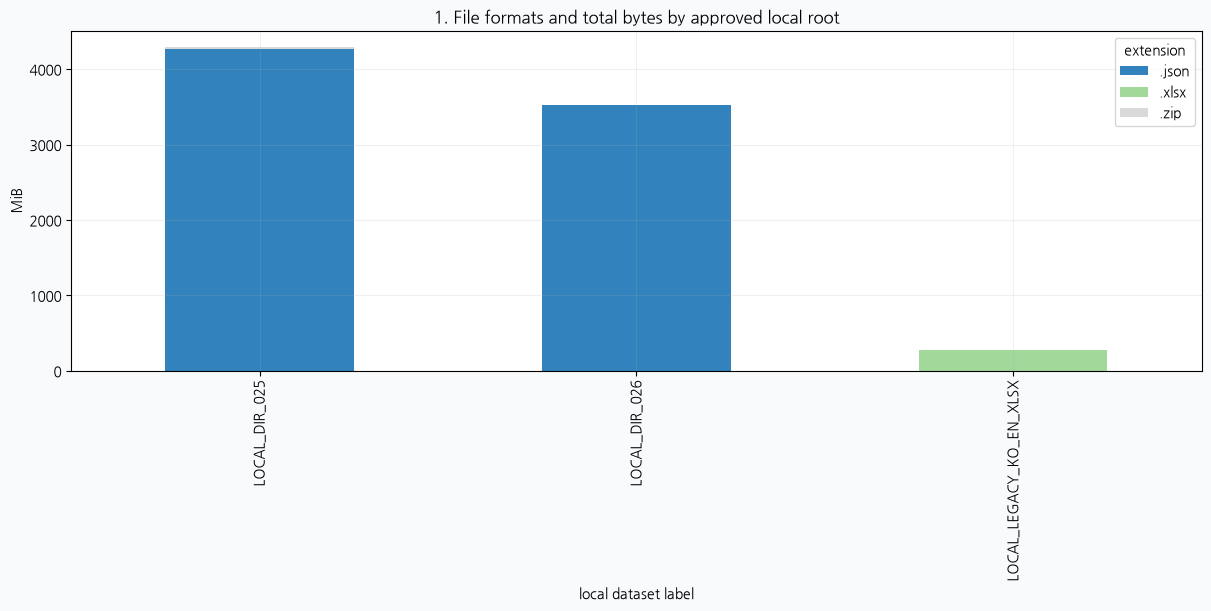

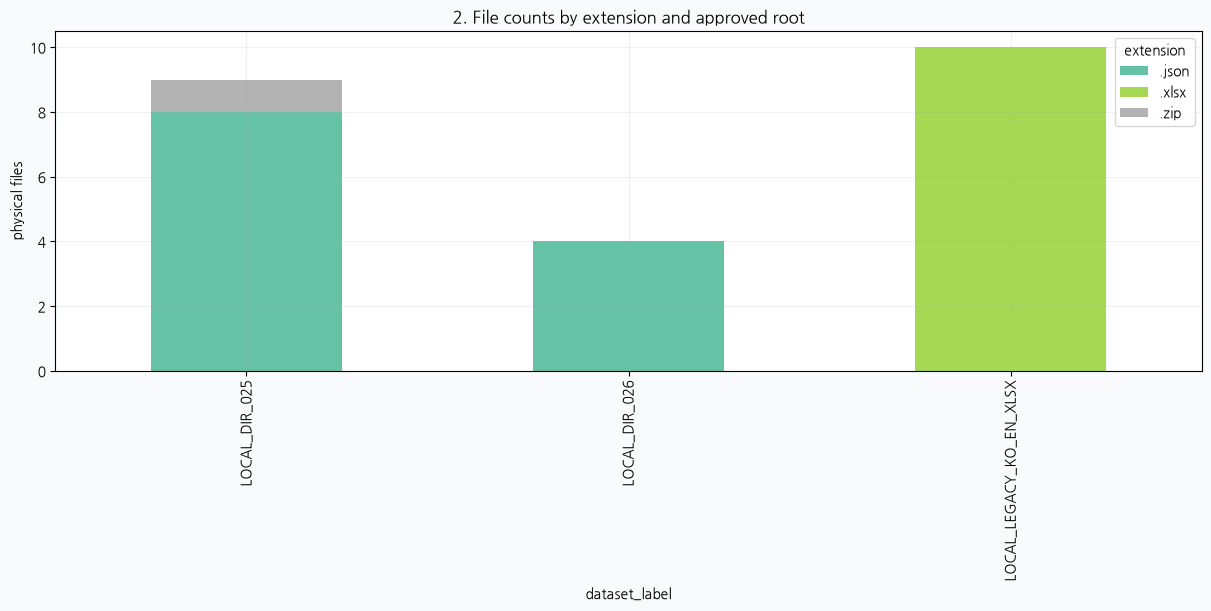

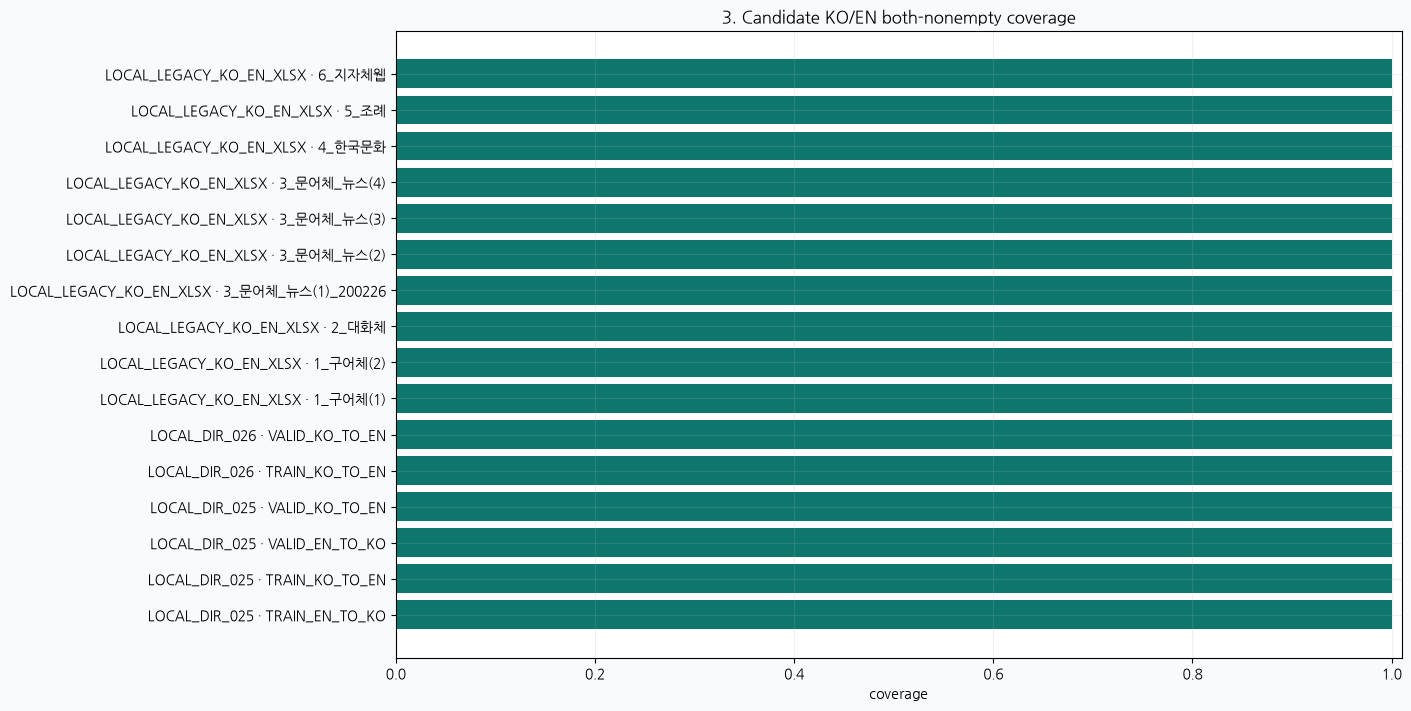

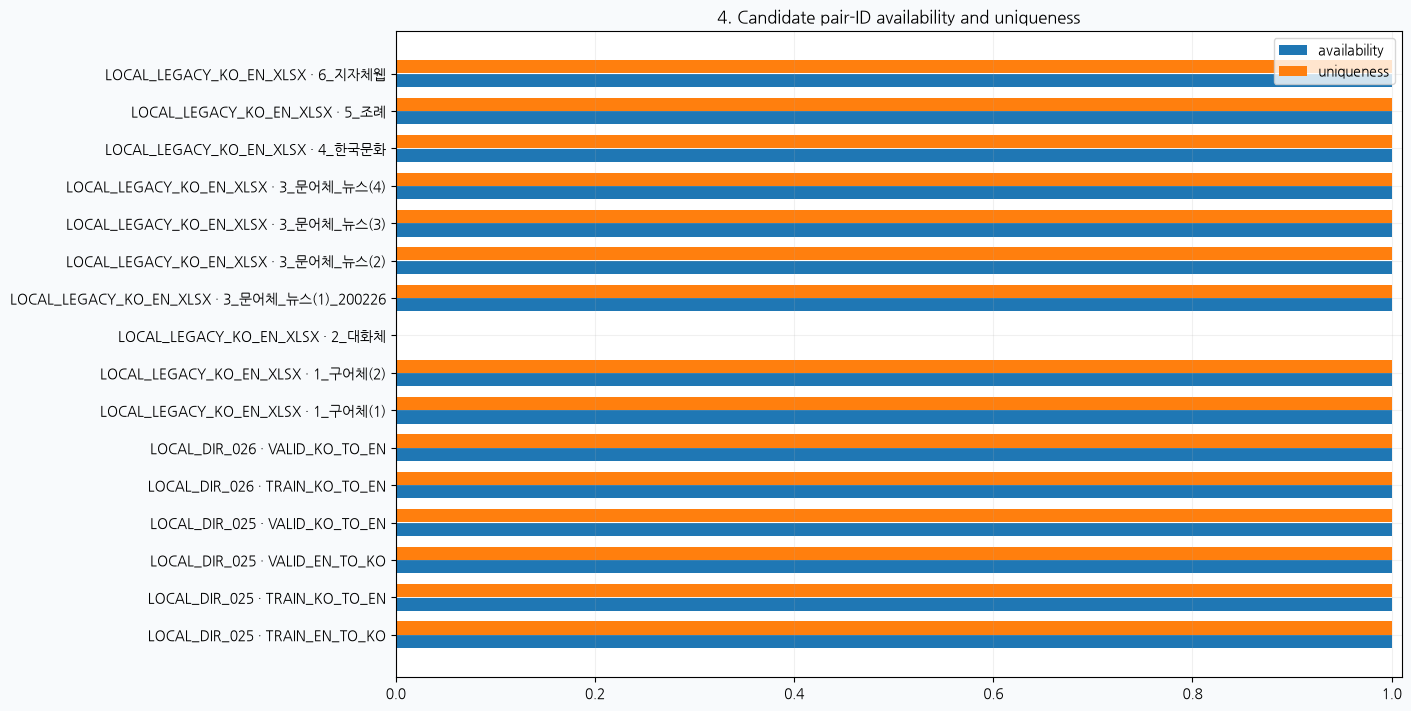

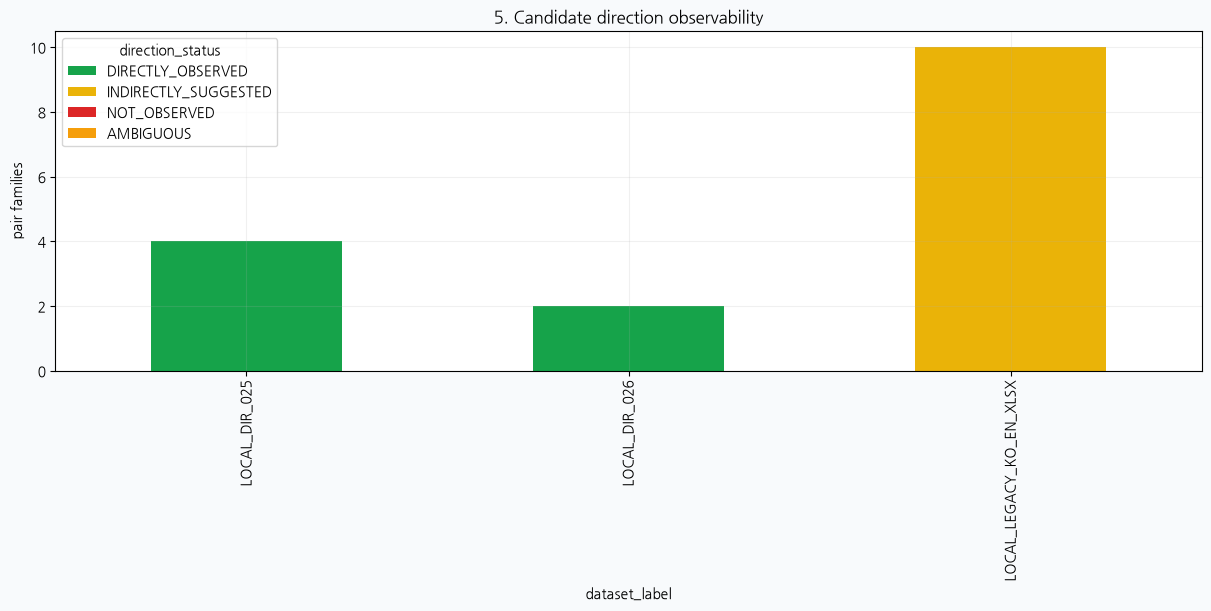

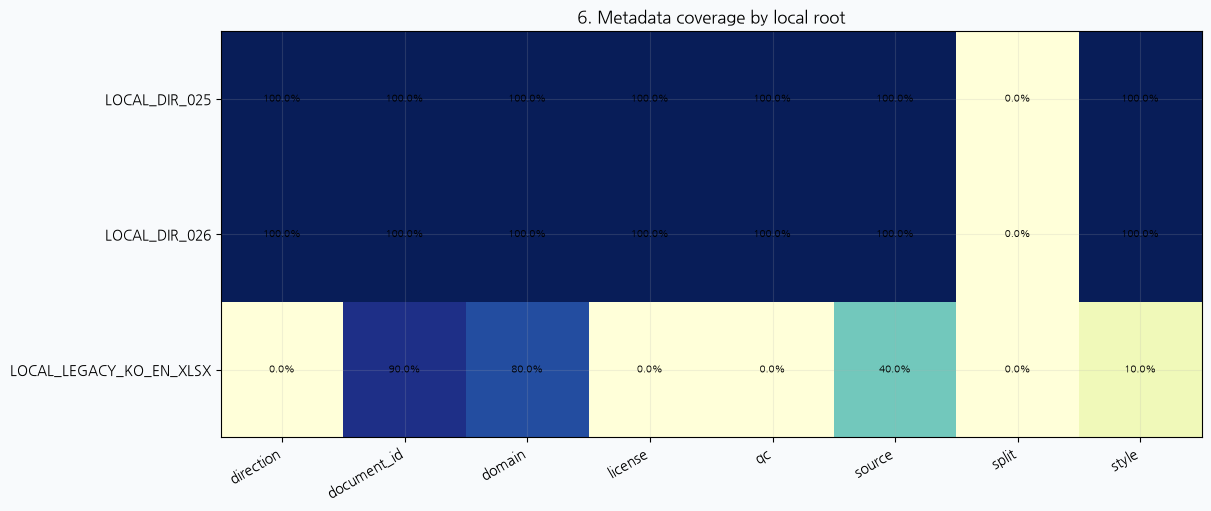

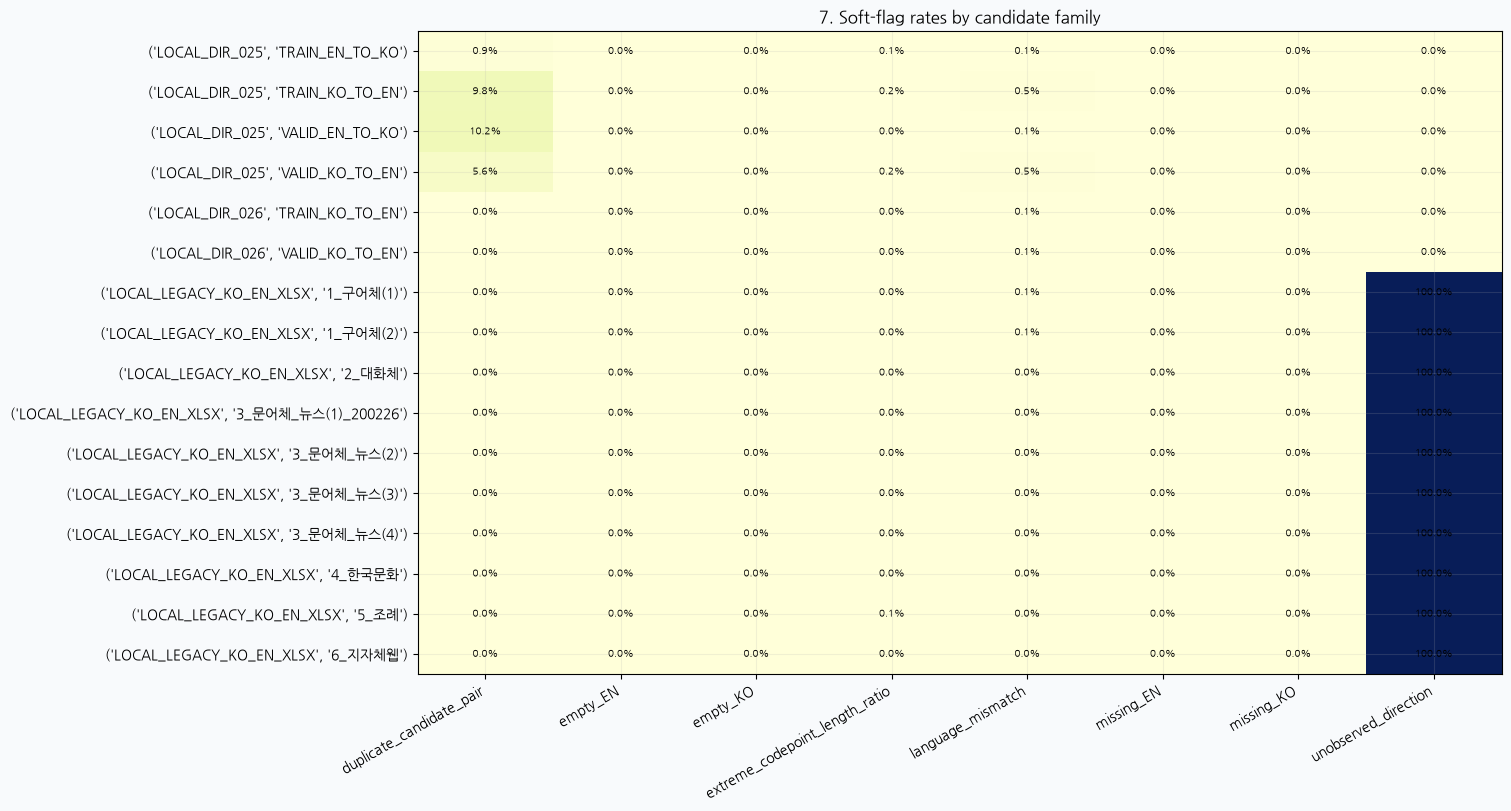

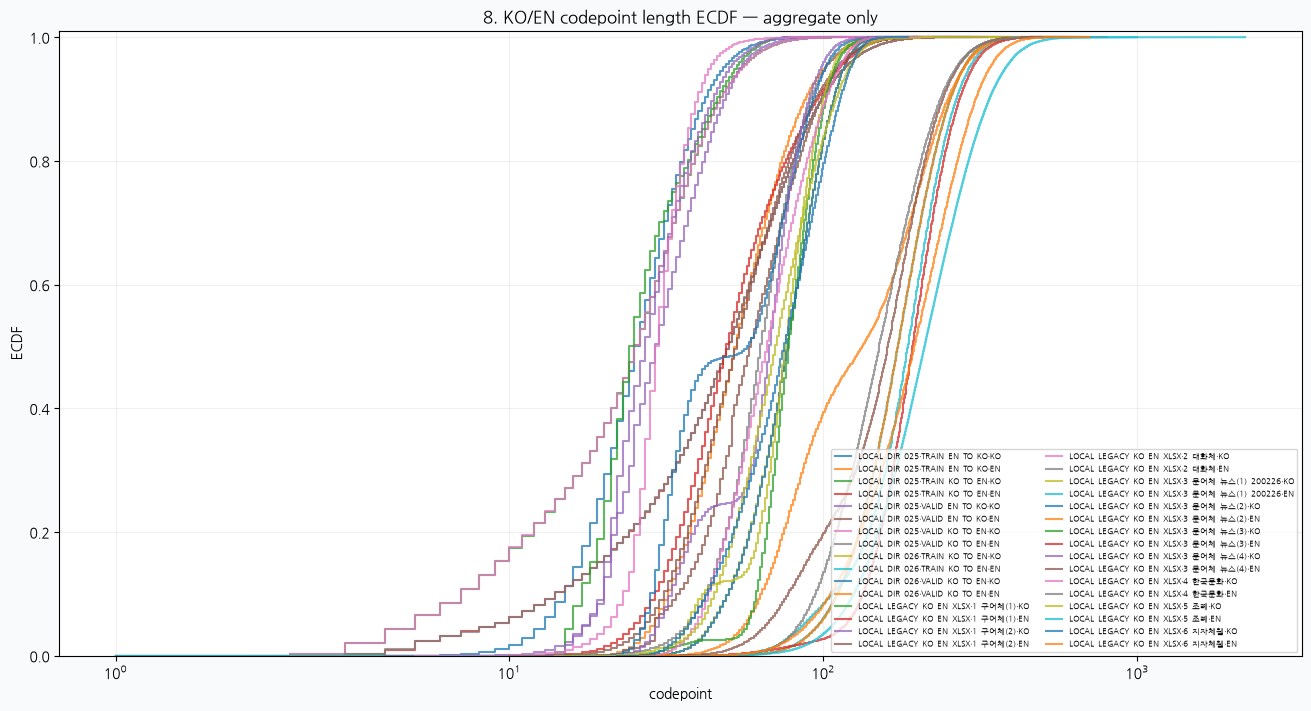

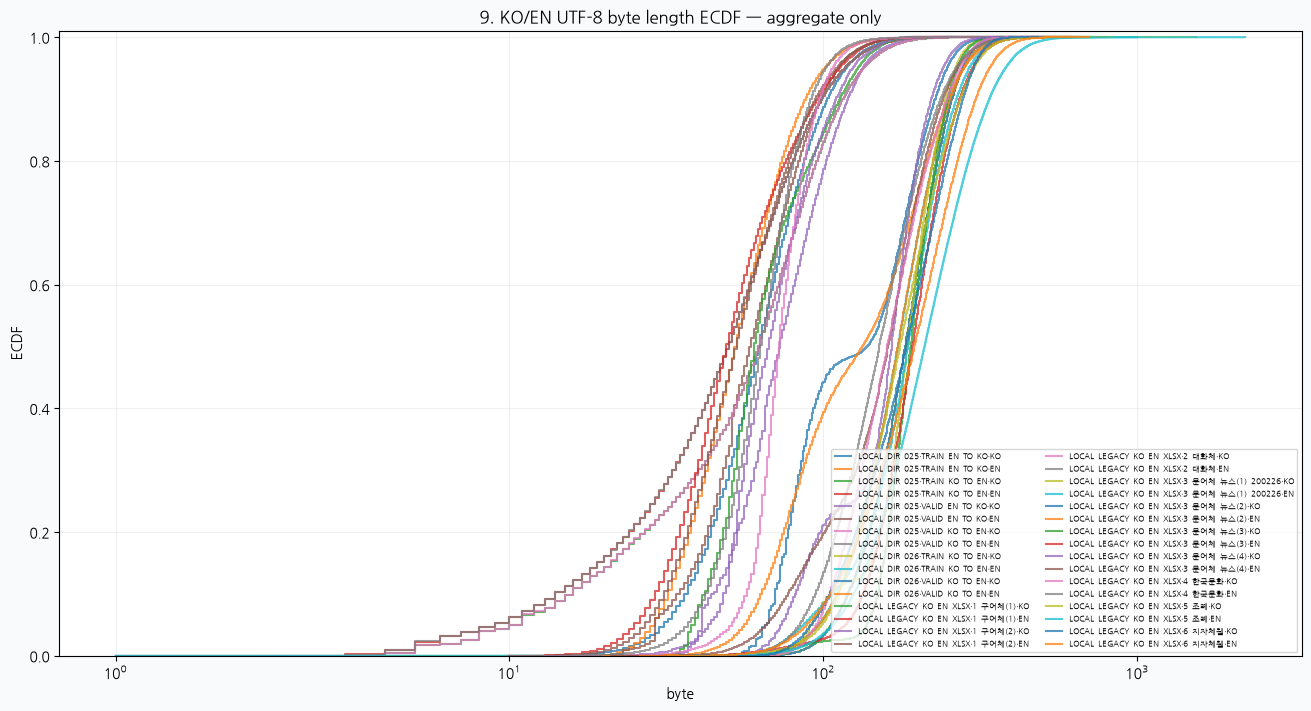

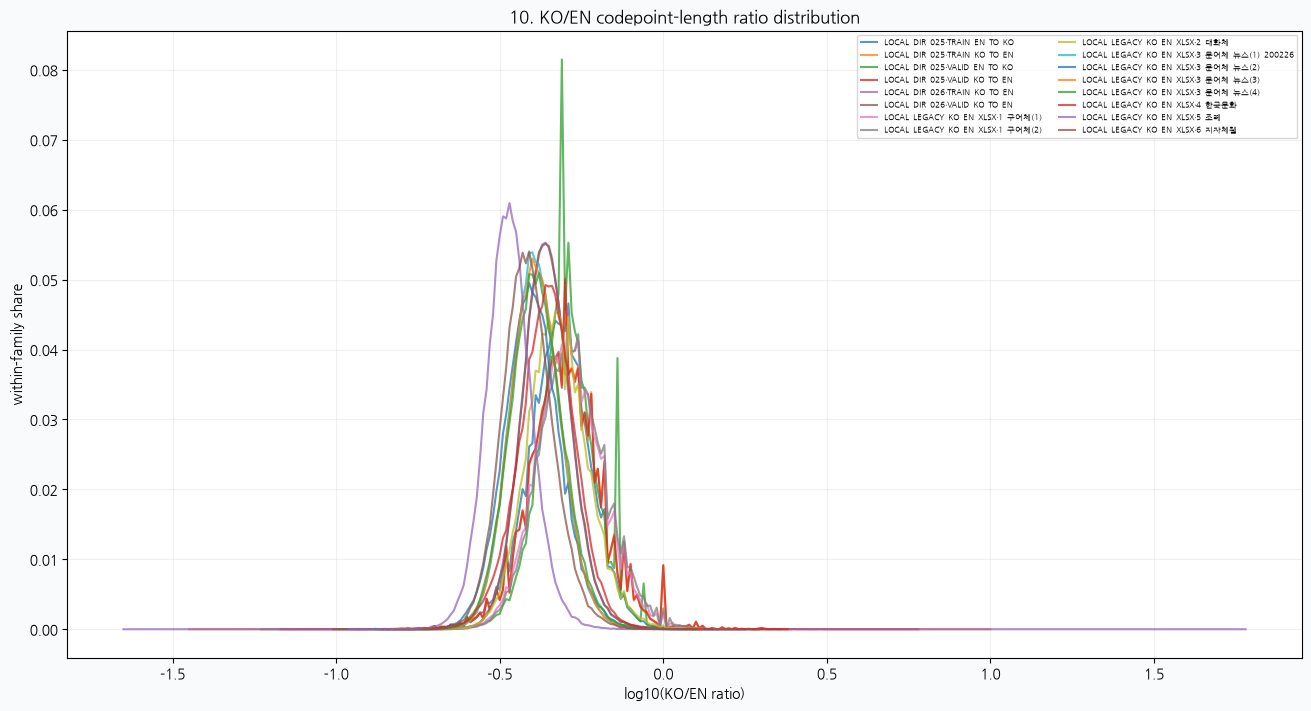

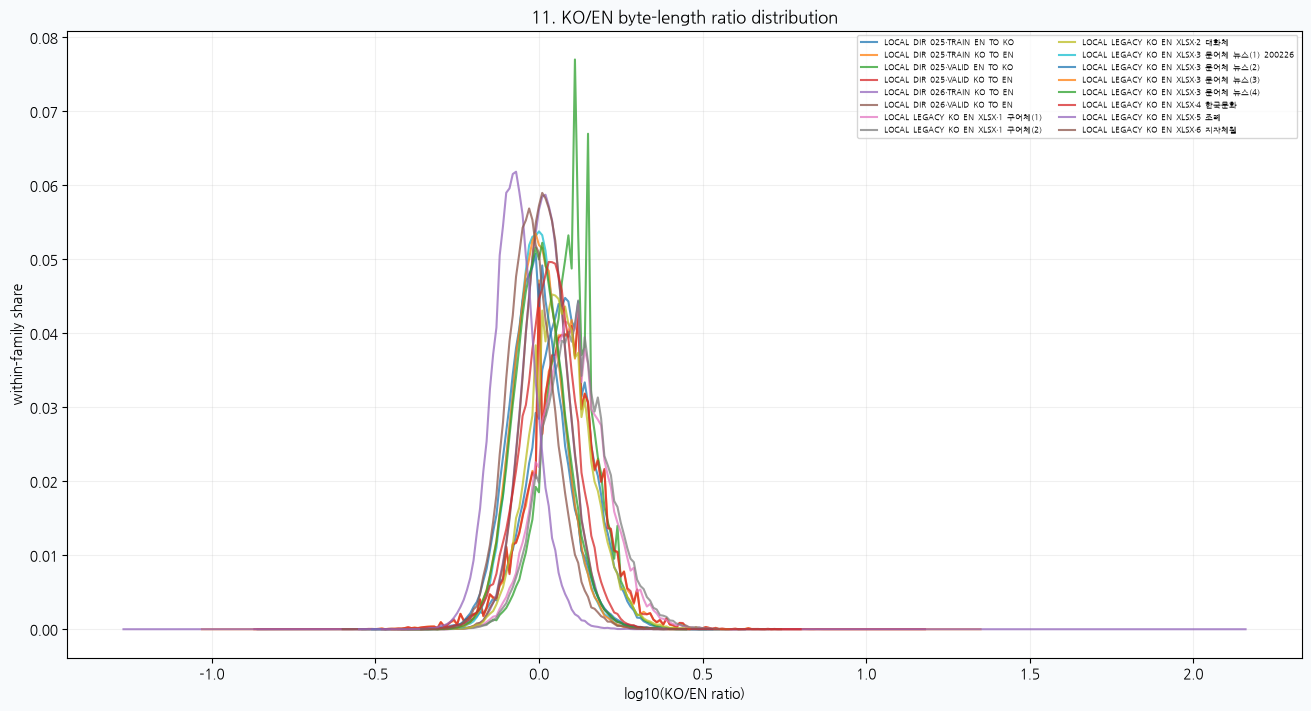

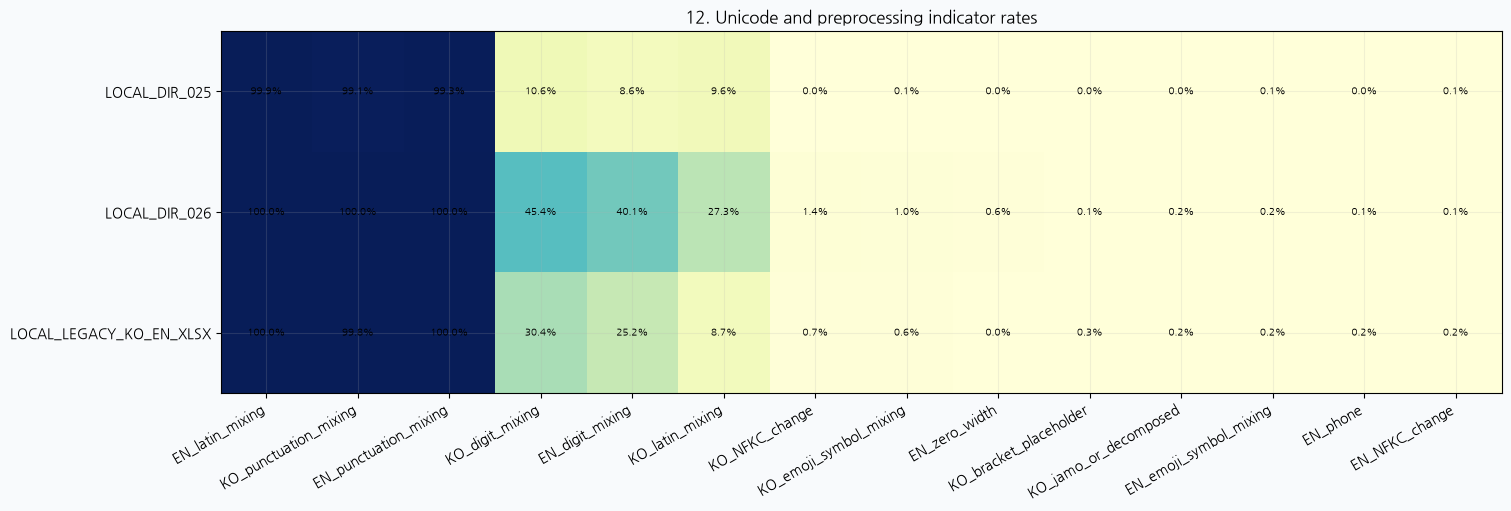

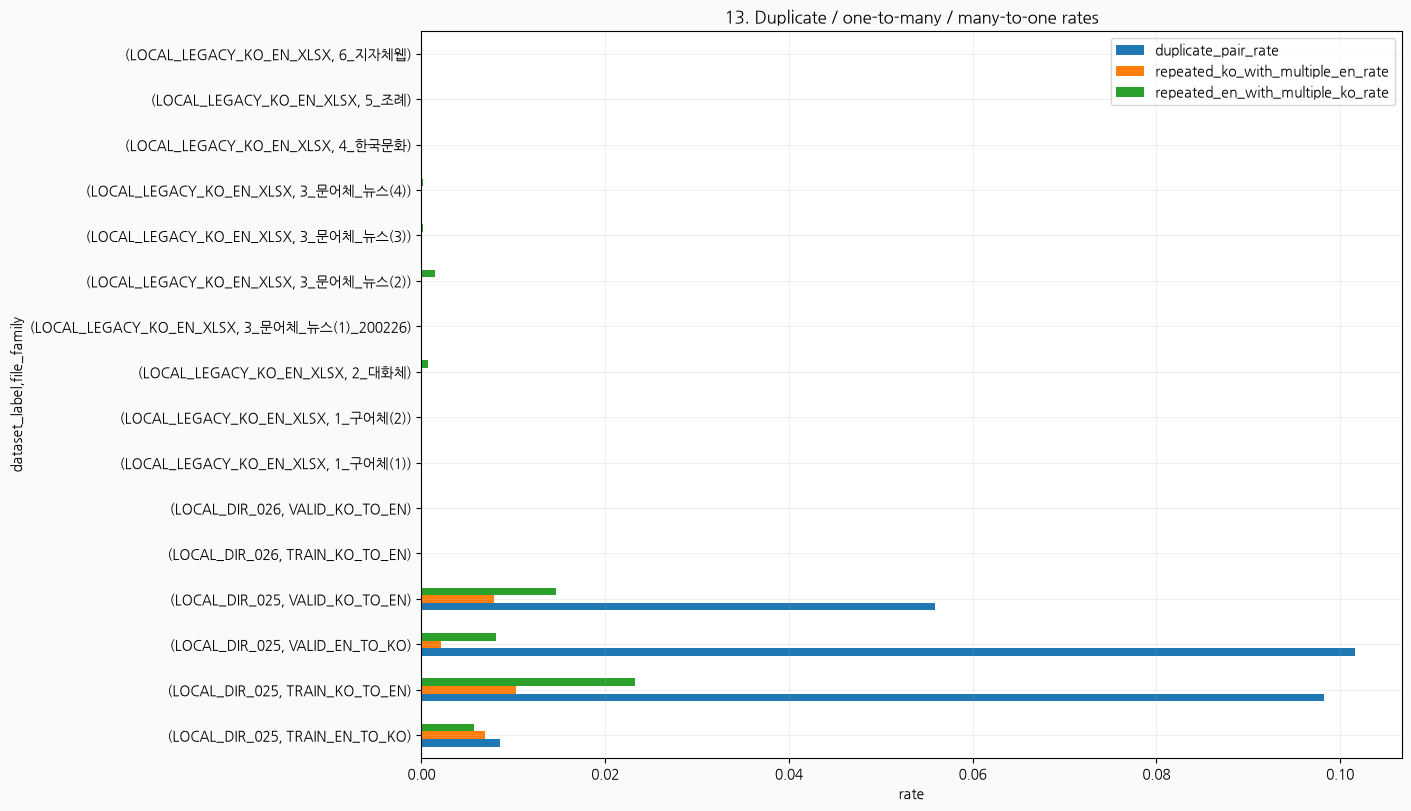

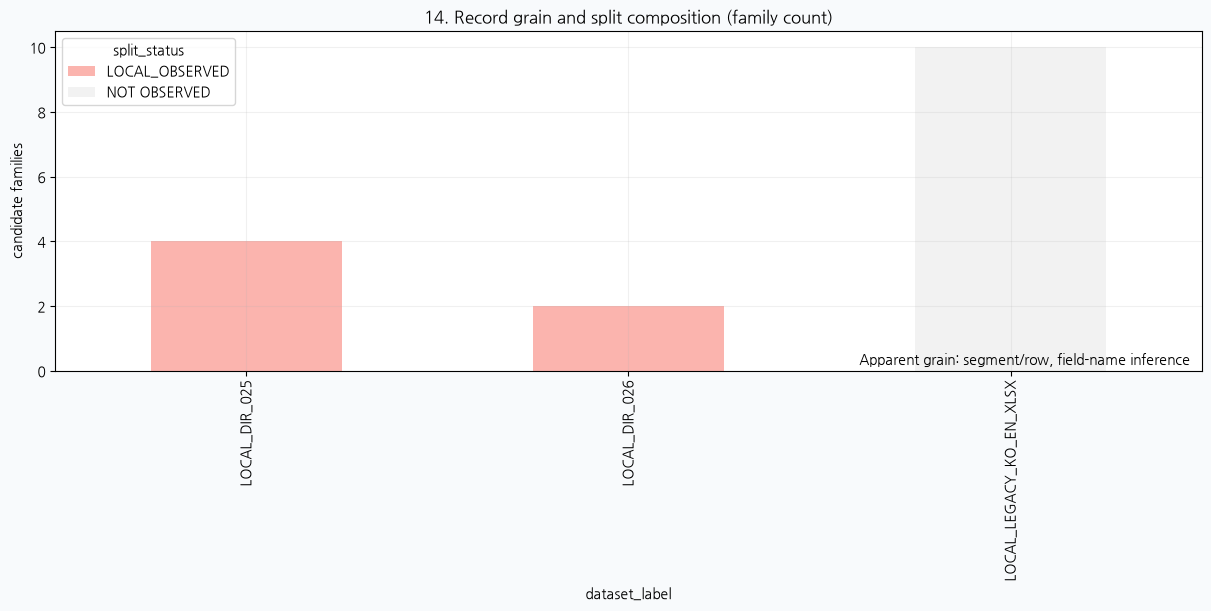

/tmp/ipykernel_48895/2867200972.py:58: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  status_code={'LOCAL_OBSERVED':3,'PARTIAL / AMBIGUOUS':2,'NOT OBSERVED':1,'WEB VERIFICATION REQUIRED':0}; matrix=dashboard.replace(status_code).astype(int)


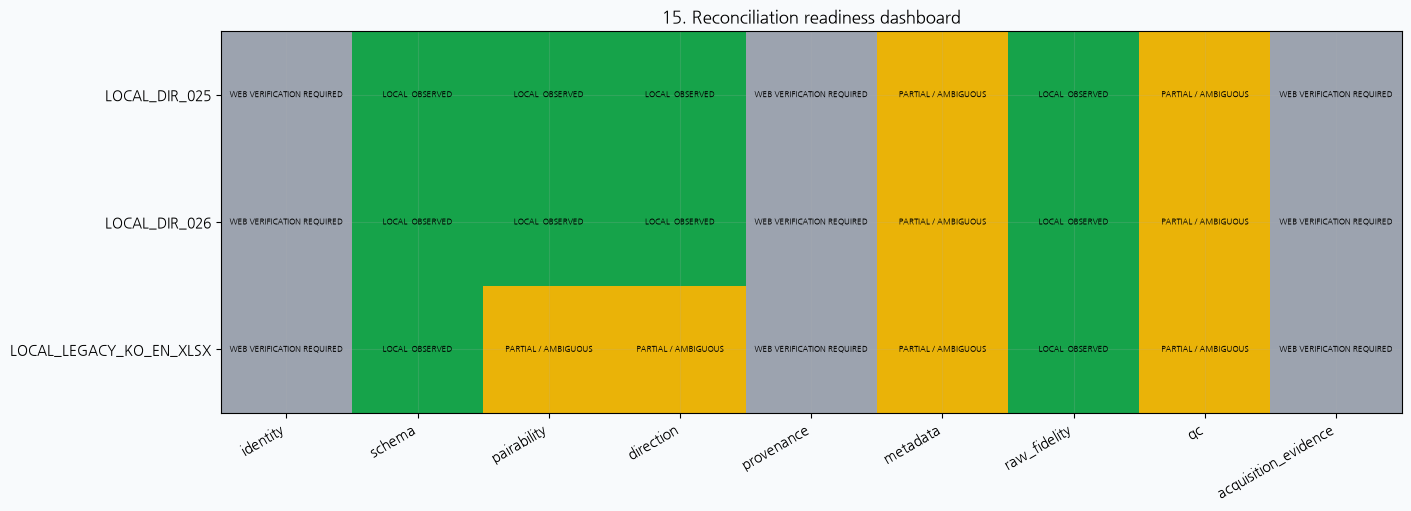

figures created: 15


In [16]:
def plot_style():
    plt.rcParams.update({'font.family':'NanumGothic','axes.unicode_minus':False,'figure.facecolor':'#F8FAFC','axes.facecolor':'white','axes.grid':True,'grid.alpha':.18,'savefig.dpi':140})

def save_plot(fig,number,slug):
    path=FIGURE_ROOT/f'{number:02d}_{slug}.png'; fig.savefig(path,bbox_inches='tight'); plt.show(); return path

def heatmap(ax,frame,title,fmt='.1%'):
    matrix=frame.fillna(0); image=ax.imshow(matrix.values,aspect='auto',cmap='YlGnBu',vmin=0,vmax=max(.001,float(matrix.values.max())))
    ax.set_xticks(range(len(matrix.columns)),matrix.columns,rotation=30,ha='right'); ax.set_yticks(range(len(matrix.index)),matrix.index)
    ax.set_title(title)
    for i in range(len(matrix.index)):
        for j in range(len(matrix.columns)):
            value=matrix.iat[i,j]; label=f'{value:.1%}' if fmt=='.1%' else f'{value:.3f}'
            ax.text(j,i,label,ha='center',va='center',fontsize=7,color='black')
    return image

def build_figures():
    plot_style(); made=[]
    fm=file_manifest_df.copy(); fm['MiB']=fm['byte_size']/2**20
    p= fm.pivot_table(index='dataset_label',columns='extension',values='MiB',aggfunc='sum',fill_value=0)
    fig,ax=plt.subplots(figsize=(12,6),constrained_layout=True); p.plot.bar(stacked=True,ax=ax,colormap='tab20c'); ax.set_title('1. File formats and total bytes by approved local root'); ax.set_ylabel('MiB'); ax.set_xlabel('local dataset label'); made.append(save_plot(fig,1,'file_formats_bytes'))
    p=fm.pivot_table(index='dataset_label',columns='extension',values='relative_file_path',aggfunc='count',fill_value=0)
    fig,ax=plt.subplots(figsize=(12,6),constrained_layout=True); p.plot.bar(stacked=True,ax=ax,colormap='Set2'); ax.set_title('2. File counts by extension and approved root'); ax.set_ylabel('physical files'); made.append(save_plot(fig,2,'file_counts_extension'))
    pa=pairability_df.copy();
    fig,ax=plt.subplots(figsize=(14,7),constrained_layout=True); ax.barh(pa['dataset_label']+' · '+pa['file_family'],pa['both_nonempty_count']/pa['total_candidate_records'],color='#0F766E'); ax.set_xlim(0,1.01); ax.set_title('3. Candidate KO/EN both-nonempty coverage'); ax.set_xlabel('coverage'); made.append(save_plot(fig,3,'both_nonempty_coverage'))
    fig,ax=plt.subplots(figsize=(14,7),constrained_layout=True); y=np.arange(len(pa)); ax.barh(y-.18,pa['pair_id_availability_rate'],height=.35,label='availability'); ax.barh(y+.18,pa['pair_id_uniqueness_rate'],height=.35,label='uniqueness'); ax.set_yticks(y,pa['dataset_label']+' · '+pa['file_family']); ax.set_xlim(0,1.01); ax.legend(); ax.set_title('4. Candidate pair-ID availability and uniqueness'); made.append(save_plot(fig,4,'pair_id_rates'))
    order=['DIRECTLY_OBSERVED','INDIRECTLY_SUGGESTED','NOT_OBSERVED','AMBIGUOUS']; counts=pa.groupby(['dataset_label','direction_status']).size().unstack(fill_value=0).reindex(columns=order,fill_value=0)
    fig,ax=plt.subplots(figsize=(12,6),constrained_layout=True); counts.plot.bar(stacked=True,ax=ax,color=['#16A34A','#EAB308','#DC2626','#F59E0B']); ax.set_title('5. Candidate direction observability'); ax.set_ylabel('pair families'); made.append(save_plot(fig,5,'direction_observability'))
    meta=metadata_coverage_df[metadata_coverage_df.metadata_concept.isin(CORE_METADATA_CONCEPTS)].pivot_table(index='dataset_label',columns='metadata_concept',values='non_null_rate',aggfunc='mean',fill_value=0)
    fig,ax=plt.subplots(figsize=(12,5),constrained_layout=True); heatmap(ax,meta,'6. Metadata coverage by local root'); made.append(save_plot(fig,6,'metadata_coverage'))
    q=quality_flags_df[quality_flags_df['flag'].isin(['missing_KO','missing_EN','empty_KO','empty_EN','language_mismatch','extreme_codepoint_length_ratio','duplicate_candidate_pair','unobserved_direction'])].pivot_table(index=['dataset_label','file_family'],columns='flag',values='rate',aggfunc='mean',fill_value=0)
    fig,ax=plt.subplots(figsize=(15,8),constrained_layout=True); heatmap(ax,q,'7. Soft-flag rates by candidate family'); made.append(save_plot(fig,7,'soft_flag_heatmap'))
    for number,metric,slug,title in [(8,'codepoint','ko_en_codepoint_ecdf','KO/EN codepoint length ECDF'),(9,'byte','ko_en_byte_ecdf','KO/EN UTF-8 byte length ECDF')]:
        fig,ax=plt.subplots(figsize=(13,7),constrained_layout=True)
        for key,hist in LENGTH_HISTS.items():
            dataset,family,language,stored_metric=key
            if stored_metric!=metric: continue
            values=sorted(hist); counts_arr=np.array([hist[v] for v in values]); cdf=np.cumsum(counts_arr)/counts_arr.sum(); ax.step(values,cdf,where='post',label=f'{dataset}·{family}·{language}',alpha=.75)
        ax.set_xscale('symlog'); ax.set_ylim(0,1.01); ax.set_title(f'{number}. {title} — aggregate only'); ax.set_xlabel(metric); ax.set_ylabel('ECDF'); ax.legend(fontsize=6,ncol=2,loc='lower right'); made.append(save_plot(fig,number,slug))
    for number,metric,slug in [(10,'codepoint','codepoint_ratio'),(11,'byte','byte_ratio')]:
        fig,ax=plt.subplots(figsize=(13,7),constrained_layout=True)
        for key,hist in RATIO_HISTS.items():
            dataset,family,stored_metric=key
            if stored_metric!=metric: continue
            xs=sorted(hist); ys=np.array([hist[x] for x in xs],dtype=float); ax.plot(xs,ys/ys.sum(),label=f'{dataset}·{family}',alpha=.75)
        ax.set_title(f'{number}. KO/EN {metric}-length ratio distribution'); ax.set_xlabel('log10(KO/EN ratio)'); ax.set_ylabel('within-family share'); ax.legend(fontsize=6,ncol=2); made.append(save_plot(fig,number,slug))
    fidelity_flags=[f for f in quality_flags_df['flag'].unique() if any(token in f for token in ['non_NFC','NFKC','replacement','control','zero_width','markup','url','email','phone','placeholder','whitespace','jamo','mixing','newline','tab'])]
    fidelity=quality_flags_df[quality_flags_df['flag'].isin(fidelity_flags)].pivot_table(index='dataset_label',columns='flag',values='rate',aggfunc='mean',fill_value=0)
    top=fidelity.max().nlargest(14).index; fidelity=fidelity[top]
    fig,ax=plt.subplots(figsize=(15,5),constrained_layout=True); heatmap(ax,fidelity,'12. Unicode and preprocessing indicator rates'); made.append(save_plot(fig,12,'unicode_preprocessing'))
    comp=pa.set_index(['dataset_label','file_family'])[['duplicate_pair_rate','repeated_ko_with_multiple_en_rate','repeated_en_with_multiple_ko_rate']]
    fig,ax=plt.subplots(figsize=(14,8),constrained_layout=True); comp.plot.barh(ax=ax); ax.set_title('13. Duplicate / one-to-many / many-to-one rates'); ax.set_xlabel('rate'); made.append(save_plot(fig,13,'duplicate_alignment'))
    split=pa.groupby(['dataset_label','split_status']).size().unstack(fill_value=0)
    fig,ax=plt.subplots(figsize=(12,6),constrained_layout=True); split.plot.bar(stacked=True,ax=ax,colormap='Pastel1'); ax.set_title('14. Record grain and split composition (family count)'); ax.set_ylabel('candidate families'); ax.text(.99,.02,'Apparent grain: segment/row, field-name inference',transform=ax.transAxes,ha='right'); made.append(save_plot(fig,14,'grain_split'))
    dashboard=pd.DataFrame(index=[d['label'] for d in DATASETS],columns=['identity','schema','pairability','direction','provenance','metadata','raw_fidelity','qc','acquisition_evidence'])
    for label in dashboard.index:
        dashboard.loc[label]=['WEB VERIFICATION REQUIRED','LOCAL_OBSERVED','LOCAL_OBSERVED' if (pa[pa.dataset_label.eq(label)].pairability_verdict=='PASS_CANDIDATE').all() else 'PARTIAL / AMBIGUOUS','LOCAL_OBSERVED' if (pa[pa.dataset_label.eq(label)].direction_status=='DIRECTLY_OBSERVED').all() else 'PARTIAL / AMBIGUOUS','WEB VERIFICATION REQUIRED','PARTIAL / AMBIGUOUS','LOCAL_OBSERVED','PARTIAL / AMBIGUOUS','WEB VERIFICATION REQUIRED']
    status_code={'LOCAL_OBSERVED':3,'PARTIAL / AMBIGUOUS':2,'NOT OBSERVED':1,'WEB VERIFICATION REQUIRED':0}; matrix=dashboard.replace(status_code).astype(int)
    from matplotlib.colors import ListedColormap
    fig,ax=plt.subplots(figsize=(14,5),constrained_layout=True); ax.imshow(matrix.values,aspect='auto',cmap=ListedColormap(['#9CA3AF','#DC2626','#EAB308','#16A34A']),vmin=0,vmax=3); ax.set_xticks(range(len(matrix.columns)),matrix.columns,rotation=30,ha='right'); ax.set_yticks(range(len(matrix.index)),matrix.index); ax.set_title('15. Reconciliation readiness dashboard')
    for i,label in enumerate(matrix.index):
        for j,col in enumerate(matrix.columns): ax.text(j,i,dashboard.loc[label,col],ha='center',va='center',fontsize=6)
    made.append(save_plot(fig,15,'reconciliation_dashboard'))
    return made

LENGTH_HISTS={}; RATIO_HISTS={}
for result in PROFILE_RESULTS:
    audit=result['audit']
    for (language,metric),hist in result['length_hist'].items(): LENGTH_HISTS[(audit['dataset_label'],audit['file_family'],language,metric)]=hist
    for metric,hist in result['ratio_hist'].items(): RATIO_HISTS[(audit['dataset_label'],audit['file_family'],metric)]=hist
FIGURES=build_figures(); print('figures created:',len(FIGURES))

# 17. Explicit Unknowns / Do-Not-Claim List

| claim | local evidence status | what local audit can establish | what it cannot establish | evidence needed from Perplexity / official web documentation |
|---|---|---|---|---|
| official AI Hub dataset ID | NOT VERIFIED | local directory names | official ID mapping | official dataset page/manifest |
| official dataset title | NOT VERIFIED | local filename labels | official title | official catalog page |
| official dataset version/release date | NOT VERIFIED | local file mtimes only | release/version | official release history |
| official total corpus size | NOT VERIFIED | local file-family record counts | official corpus size | official statistics |
| official train/validation/test definition | PARTIAL / AMBIGUOUS | local directories/fields | official split policy | official schema/guide |
| official sentence/utterance/document grain | AMBIGUOUS | nesting and field names | official unit definition | official annotation guide |
| official 1:1 alignment guarantee | NOT VERIFIED | local candidate row mapping | semantic/official guarantee | official alignment specification |
| official human translation status | NOT VERIFIED | observed field names | human translation claim | official methodology |
| official MT/post-editing status | NOT VERIFIED | local `mt`-like field presence | official MT/post-edit workflow | official methodology |
| official translation validation workflow | NOT VERIFIED | no workflow documentation | reviewer/validation process | official QA guide |
| official source/domain provenance | PARTIAL / AMBIGUOUS | local metadata field coverage | official provenance | official data description |
| official preprocessing pipeline | NOT VERIFIED | aggregate Unicode indicators | named official pipeline | official preprocessing docs |
| official license and research-use terms | NOT VERIFIED | local license-like field presence | legal terms | official license page |
| official redistribution restriction | NOT VERIFIED | nothing authoritative | redistribution rights | official terms |
| official schema specification | NOT VERIFIED | locally observed keys/types | official schema contract | official schema/download guide |
| Tier A/B/C eligibility | NOT EVALUATED | no Tier decision | final eligibility | Research Director decision after reconciliation |


# 18. Export Validation and Artifact Manifest

Required outputs, privacy constraints, approved-root scope, and raw immutability are checked before the final console report.

In [17]:
required=['aihub_local_recon_summary.md','aihub_dataset_inventory.csv','aihub_file_manifest.csv','aihub_schema_inventory.csv','aihub_pairability_audit.csv','aihub_metadata_coverage.csv','aihub_quality_flags.csv','aihub_reconciliation_packet.json','notebook_inventory.csv']
relevant_paths=RELEVANT_NOTEBOOKS
summary_lines=['# AIHUB LOCAL RECON COMPLETE','','## Scope','- Allowed roots inspected: 3','- Other raw datasets inspected: 0','- Raw files modified: 0','- Raw text exported: 0','','## Existing Notebook Handoff',f'- Existing notebook count: {len(notebook_inventory_df)}','- AI Hub relevant notebook paths: '+(' | '.join(relevant_paths) if relevant_paths else 'NONE'),'- New notebook path: notebooks/exploratory/evidence/AIHUB_LOCAL_RECON_EVIDENCE_EXPORT_20260816.ipynb','- Reused notebook logic: streaming aggregate patterns only; all results re-run from raw','- Existing notebook files to provide Perplexity: '+(' | '.join(relevant_paths) if relevant_paths else 'NONE'),'','## Candidate Dataset Summary']
for packet in packets:
    label=packet['local_dataset_label']; audits=pairability_df[pairability_df.dataset_label.eq(label)]; flags=quality_flags_df[(quality_flags_df.dataset_label.eq(label)) & quality_flags_df.status.eq('SOFT_FLAG_ONLY')]
    top_flags=flags.groupby('flag').rate.mean().nlargest(3)
    summary_lines.extend([f'### {label}','- official ID/title/version: NOT VERIFIED',f"- parseable file count: {int(file_manifest_df[(file_manifest_df.dataset_label.eq(label)) & file_manifest_df.parsing_status.eq('PARSEABLE')].shape[0])}",'- apparent record grain: segment/row; AMBIGUOUS field-name inference',f"- strongest candidate KO/EN field pair: {' | '.join(sorted(set(audits.candidate_ko_field_path+' + '+audits.candidate_en_field_path)))}",f"- candidate pair-ID status: mean availability {audits.pair_id_availability_rate.mean():.6f}",f"- candidate direction status: {' | '.join(sorted(set(audits.direction_status)))}",f"- pairability verdict: {packet['ko_en_mapping']['pairability_verdict']}",f"- major metadata fields observed: {' | '.join(packet['metadata']['source_fields']+packet['metadata']['domain_fields']+packet['metadata']['style_fields']+packet['metadata']['license_fields'])}",f"- major preprocessing indicators: aggregate rates in aihub_quality_flags.csv",f"- major soft-flag rates: {json.dumps(top_flags.round(8).to_dict(),sort_keys=True)}",'- top unresolved questions for Perplexity: official identity, split/grain, translation workflow, license'])
summary_lines.extend(['','## Reconciliation Package','- Markdown report: outputs/aihub_recon_g1/aihub_local_recon_summary.md','- CSV inventory: outputs/aihub_recon_g1/aihub_dataset_inventory.csv | outputs/aihub_recon_g1/aihub_file_manifest.csv','- CSV schema: outputs/aihub_recon_g1/aihub_schema_inventory.csv','- CSV pairability: outputs/aihub_recon_g1/aihub_pairability_audit.csv','- JSON reconciliation packet: outputs/aihub_recon_g1/aihub_reconciliation_packet.json','- Figures directory: outputs/aihub_recon_g1/figures/','','## Interpretation Boundary','- LOCAL_OBSERVED evidence is not official documentation.','- No final source rank or Tier A/B/C decision was made.','- Perplexity must reconcile local evidence against official AI Hub documentation.'])
(OUTPUT_ROOT/'aihub_local_recon_summary.md').write_text('\n'.join(summary_lines)+'\n',encoding='utf-8')

missing=[name for name in required if not (OUTPUT_ROOT/name).exists()]; assert not missing, missing
assert len(list(FIGURE_ROOT.glob('*.png')))==15
current_state={safe_rel(p):(p.stat().st_size,p.stat().st_mtime_ns) for item in DATASETS for p in item['root'].rglob('*') if p.is_file()}; assert current_state==RAW_START_STATE
assert set(file_manifest_df.dataset_label)=={d['label'] for d in DATASETS}
assert not any(col.lower() in {'raw_text','text_hash','ko_hash','en_hash'} for df in [dataset_inventory_df,file_manifest_df,schema_inventory_df,pairability_df,metadata_coverage_df,quality_flags_df,notebook_inventory_df] for col in df.columns)
for path in [OUTPUT_ROOT/name for name in required]:
    text=path.read_text(encoding='utf-8')
    assert '<REDACTED_TEXT>' not in text
    if path.suffix in {'.csv','.json'}:
        assert not EMAIL_RE.search(text), f'email-like output: {path.name}'
        assert not re.search(r'(?i)https?://|www\.',text), f'URL-like output: {path.name}'
    if path.suffix == '.csv':
        exported=pd.read_csv(path,dtype=str,keep_default_na=False)
        for column in exported.columns:
            for value in exported[column]:
                assert len(value) <= 200 or 'path' in column.lower(), f'overlong non-path output: {path.name}:{column}'
                technical_column=any(token in column.lower() for token in ['path','time','sha','byte','count','rate','size','length','record','detail','type','manifest'])
                if not technical_column and not re.fullmatch(r'[0-9.eE+\-]+',value):
                    assert not PHONE_RE.search(value), f'phone-like output: {path.name}:{column}'

artifact_rows=[]
artifact_paths=[OUTPUT_ROOT/name for name in required]+sorted(FIGURE_ROOT.glob('*.png'))
for path in artifact_paths:
    artifact_rows.append({'relative_path':safe_rel(path),'bytes':path.stat().st_size,'sha256':sha256_file(path)})
artifact_manifest_df=pd.DataFrame(artifact_rows); display(artifact_manifest_df)
print('\n'.join(summary_lines))
print(f'Parse errors or unreadable files: {len(parse_errors)}')
if parse_errors: display(pd.DataFrame(parse_errors))


,relative_path,bytes,sha256
0,outputs/aihub_recon_g1/aihub_local_recon_summa...,4003,ea07e8cebdea99ef8b0bed9d6ad51faa2519121d47018a...
1,outputs/aihub_recon_g1/aihub_dataset_inventory...,912,abac6417e6235a3c5224a21a8a469f0e1ea9b8c316be49...
2,outputs/aihub_recon_g1/aihub_file_manifest.csv,9713,0fcc017ccd17721af15dcb0f2c9cf28efac5920b6bca78...
3,outputs/aihub_recon_g1/aihub_schema_inventory.csv,41627,fc44f472b3a5ed4712edd9ac1e7b073ea45eaf0d283789...
4,outputs/aihub_recon_g1/aihub_pairability_audit...,12408,a4ba10109897d96d2048ffa544f132276c91c320912950...
5,outputs/aihub_recon_g1/aihub_metadata_coverage...,27638,0fc75e86ee60cc8563b27d244fdc5b6719b58cec7562c6...
6,outputs/aihub_recon_g1/aihub_quality_flags.csv,144247,6593ad48f30646623f7302fab027feef9f3f5b85211227...
7,outputs/aihub_recon_g1/aihub_reconciliation_pa...,24821,de8131caebdb35497a3fc59c28c8e9fab9fe4420914dfd...
8,outputs/aihub_recon_g1/notebook_inventory.csv,1146,b1d9ff501b3b8c633a918d83af1c3278151dca1d718e9e...
9,outputs/aihub_recon_g1/figures/01_file_formats...,39911,175b970d540da939ed1ecb02144efd6af34415758d6658...


# AIHUB LOCAL RECON COMPLETE

## Scope
- Allowed roots inspected: 3
- Other raw datasets inspected: 0
- Raw files modified: 0
- Raw text exported: 0

## Existing Notebook Handoff
- Existing notebook count: 4
- AI Hub relevant notebook paths: notebooks/exploratory/raw/EDA_RAW_AIHUB_025_G1_SANITIZED.ipynb | notebooks/exploratory/raw/EDA_RAW_AIHUB_026_G1_SANITIZED.ipynb | notebooks/exploratory/raw/EDA_RAW_LEGACY_KO_EN_XLSX_G1_SANITIZED.ipynb
- New notebook path: notebooks/exploratory/evidence/AIHUB_LOCAL_RECON_EVIDENCE_EXPORT_20260816.ipynb
- Reused notebook logic: streaming aggregate patterns only; all results re-run from raw
- Existing notebook files to provide Perplexity: notebooks/exploratory/raw/EDA_RAW_AIHUB_025_G1_SANITIZED.ipynb | notebooks/exploratory/raw/EDA_RAW_AIHUB_026_G1_SANITIZED.ipynb | notebooks/exploratory/raw/EDA_RAW_LEGACY_KO_EN_XLSX_G1_SANITIZED.ipynb

## Candidate Dataset Summary
### LOCAL_DIR_025
- official ID/title/version: NOT VERIFIED
- parseable file count: 9
- 